# Проект: Анализ пространственно-временной динамики ареала лебедей в США

---

Выполнила: *Мартынова Наталья*

Дата: *сентябрь 2026 г.*

---

## Тема проекта

**Анализ пространственно-временной динамики ареала лебедей в США.**

---

## Цель проекта

Определить, наблюдается ли статистически значимое смещение ареала лебедей в США, и выявить, различается ли это смещение в разных географических зонах. Оценить влияние внешних факторов (температура, плотность населения) на пространственное распределение птиц.

---

## Задачи проекта

1. Загрузить и очистить данные о наблюдениях за лебедями.
2. Добавить внешние данные (плотность населения и температура по штатам и провинциям).
3. Провести кластерный анализ для выделения географических зон.
4. Учесть сезонность и другие искажающие факторы.
5. Провести статистический анализ: оценить тренды, сравнить виды и сезоны.
6. Построить визуализации (не менее 4 графиков).
7. Сформулировать выводы.

---

## Данные

Данные представлены в виде 4-х файлов: 

- `short.csv` - Наблюдения за лебедями (6 видов, 1980–2024) - ~3.5 млн записей
- `US_CA.csv` - Плотность населения штатов США и провинций Канады - 69 записей
- `us_state_temperatures.csv` - Среднемесячные температуры по штатам США - ~26 868 записей
- `canada_temperatures.csv` - Среднемесячные температуры по провинциям Канады - 6 864 записи

Источник: GBIF (Global Biodiversity Information Facility)

---

## 1. Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress, kruskal, mannwhitneyu, pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols
from itertools import combinations
from statsmodels.stats.multitest import multipletests

sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

## 2. Загрузка данных

In [2]:
data = pd.read_csv('short.csv')
data.info()
print(data.shape)
print(data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 22 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   gbifID                         int64  
 1   basisOfRecord                  object 
 2   recordedBy                     object 
 3   eventDate                      object 
 4   year                           int64  
 5   month                          int64  
 6   day                            int64  
 7   countryCode                    object 
 8   stateProvince                  object 
 9   locality                       object 
 10  decimalLatitude                float64
 11  decimalLongitude               float64
 12  coordinateUncertaintyInMeters  float64
 13  coordinatePrecision            float64
 14  infraspecificEpithet           float64
 15  taxonRank                      object 
 16  datasetKey                     object 
 17  elevation                      float64
 18  el

Набор данных состоит из 3 489 498 строк и 22 столбцов. Представляет собой реестр наблюдений за биоразнообразием с информацией о видах, датах и географических координатах. Анализ полноты показывает, что 14 столбцов (включая ключевые идентификаторы, таксономию и широту/долготу) не имеют пропусков, а в поле `locality` отсутствует всего 4 значения. При этом 7 числовых столбцов, отвечающих за метрики точности координат, высоту и глубину (например, `coordinateUncertaintyInMeters`, `elevation`, `depth`), а также поле `infraspecificEpithet`, содержат 100% пропусков (ровно 3 489 498 отсутствующих значений) и подлежат удалению на этапе предобработки в силу полного отсутствия информационной ценности.

## 3. Удаление пустых столбцов

> TODO: удалите столбцы, полностью состоящие из пропусков, и столбец `locality`.

In [3]:
# Удаляем из датасета data 8 столбцов: locality, coordinateUncertaintyInMeters, coordinatePrecision, infraspecificEpithet,
# elevation, elevationAccuracy, depth, depthAccuracy
data = data.drop(columns=['locality', 'coordinateUncertaintyInMeters', 'coordinatePrecision', 'infraspecificEpithet', 'elevation', 'elevationAccuracy', 'depth', 'depthAccuracy'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 14 columns):
 #   Column            Dtype  
---  ------            -----  
 0   gbifID            int64  
 1   basisOfRecord     object 
 2   recordedBy        object 
 3   eventDate         object 
 4   year              int64  
 5   month             int64  
 6   day               int64  
 7   countryCode       object 
 8   stateProvince     object 
 9   decimalLatitude   float64
 10  decimalLongitude  float64
 11  taxonRank         object 
 12  datasetKey        object 
 13  species           object 
dtypes: float64(2), int64(4), object(8)
memory usage: 372.7+ MB


In [4]:
data.isna().sum()

gbifID              0
basisOfRecord       0
recordedBy          0
eventDate           0
year                0
month               0
day                 0
countryCode         0
stateProvince       0
decimalLatitude     0
decimalLongitude    0
taxonRank           0
datasetKey          0
species             0
dtype: int64

Удаление 8-ми столбцов прошло успешно. В датасете осталось 14 столбцов без пропусков.

## 4. Переименование столбцов в snake_case

> TODO: примените функцию `camel_to_snake` ко всем столбцам.

In [5]:
# Названия столбцов до переименования
data.columns

Index(['gbifID', 'basisOfRecord', 'recordedBy', 'eventDate', 'year', 'month',
       'day', 'countryCode', 'stateProvince', 'decimalLatitude',
       'decimalLongitude', 'taxonRank', 'datasetKey', 'species'],
      dtype='object')

In [6]:
def camel_to_snake(name):
    '''Преобразует CamelCase в snake_case.'''
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

In [7]:
# Применим функцию camel_to_snake() к столбцам датасета
data.columns = [camel_to_snake(col) for col in data.columns]

# Названия столбцов после переименования
data.columns

Index(['gbif_id', 'basis_of_record', 'recorded_by', 'event_date', 'year',
       'month', 'day', 'country_code', 'state_province', 'decimal_latitude',
       'decimal_longitude', 'taxon_rank', 'dataset_key', 'species'],
      dtype='object')

Переименование столбцов датасета прошло успешно.

## 5. Преобразование типа event_date

> TODO: приведите `event_date` к `datetime`.

In [8]:
# Преобразуем тип данных в столбце event_date к datetime
data['event_date'] = pd.to_datetime(data['event_date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 14 columns):
 #   Column             Dtype         
---  ------             -----         
 0   gbif_id            int64         
 1   basis_of_record    object        
 2   recorded_by        object        
 3   event_date         datetime64[ns]
 4   year               int64         
 5   month              int64         
 6   day                int64         
 7   country_code       object        
 8   state_province     object        
 9   decimal_latitude   float64       
 10  decimal_longitude  float64       
 11  taxon_rank         object        
 12  dataset_key        object        
 13  species            object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(7)
memory usage: 372.7+ MB


Преобразование типа прошло успешно.

## 6. Фильтрация данных

> TODO:
> - оставить только три вида: `Cygnus olor`, `Cygnus buccinator`, `Cygnus columbianus`;
> - оставить только US и CA;
> - ограничить координаты (широта 25–75°, долгота −170…−35°);
> - удалить столбцы с единственным уникальным значением.

In [9]:
data.head()

,gbif_id,basis_of_record,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,taxon_rank,dataset_key,species
0,938888072,HUMAN_OBSERVATION,obsr137539,2008-01-19,2008,1,19,US,Massachusetts,42.041756,-70.193480,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,Cygnus olor
1,3511818940,HUMAN_OBSERVATION,obsr902368,2021-01-23,2021,1,23,US,Massachusetts,42.222797,-72.608850,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,Cygnus olor
2,5474067204,HUMAN_OBSERVATION,obsr440493,2024-03-21,2024,3,21,US,New York,40.953114,-73.701225,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,Cygnus olor
3,3264353040,HUMAN_OBSERVATION,obsr305952,2020-05-28,2020,5,28,CA,Ontario,43.231647,-81.911110,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,Cygnus olor
4,3630533474,HUMAN_OBSERVATION,obsr1312860,2021-09-09,2021,9,9,CA,Ontario,43.155900,-79.176960,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,Cygnus buccinator


In [10]:
# Отфильтруем датасет по видам лебедей
data_filt = data[(data['species'] == 'Cygnus olor') | (data['species'] == 'Cygnus buccinator') | (data['species'] == 'Cygnus columbianus')]
data_filt['species'].unique()

array(['Cygnus olor', 'Cygnus buccinator', 'Cygnus columbianus'],
      dtype=object)

In [11]:
# Отфильтруем датасет по коду страны
data_filt = data_filt[(data_filt['country_code'] == 'US') | (data_filt['country_code'] == 'CA')]
data_filt['country_code'].unique()

array(['US', 'CA'], dtype=object)

In [12]:
# Отфильтруем датасет по координатам
data_filt = data_filt[(data_filt['decimal_latitude'] > 25) & (data_filt['decimal_latitude'] < 75) & (data_filt['decimal_longitude'] > -170) & (data_filt['decimal_longitude'] < -35)]
data_filt['decimal_latitude'].describe()

count    3.477414e+06
mean     4.299562e+01
std      4.558215e+00
min      2.525389e+01
25%      4.074377e+01
50%      4.239741e+01
75%      4.403759e+01
max      7.428330e+01
Name: decimal_latitude, dtype: float64

In [13]:
data_filt['decimal_longitude'].describe()

count    3.477414e+06
mean    -8.753679e+01
std      1.798211e+01
min     -1.696069e+02
25%     -9.092027e+01
50%     -8.152811e+01
75%     -7.526015e+01
max     -5.269413e+01
Name: decimal_longitude, dtype: float64

In [14]:
# Проверяем отфильтрованный датасет на число уникальных признаков в столбцах
data_filt.nunique()

gbif_id              3477414
basis_of_record            1
recorded_by           133457
event_date             16041
year                      45
month                     12
day                       31
country_code               2
state_province            62
decimal_latitude      326558
decimal_longitude     331078
taxon_rank                 1
dataset_key                1
species                    3
dtype: int64

In [15]:
# Удалим столбцы с единственным уникальным значением: basis_of_record, taxon_rank, dataset_key
data_filt = data_filt.drop(columns=['basis_of_record', 'taxon_rank', 'dataset_key'])
data_filt.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3477414 entries, 0 to 3489497
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   gbif_id            int64         
 1   recorded_by        object        
 2   event_date         datetime64[ns]
 3   year               int64         
 4   month              int64         
 5   day                int64         
 6   country_code       object        
 7   state_province     object        
 8   decimal_latitude   float64       
 9   decimal_longitude  float64       
 10  species            object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 318.4+ MB


В результате фильтрации датасет уменьшился с 3 489 498 до 3 477 414 строк (удалено 12 084 записи, не попавших в заданный географический диапазон) и с 14 до 11 столбцов - были удалены 3 категориальных столбца типа `object`: `basis_of_record`, `taxon_rank` и `dataset_key` (как содержащие единственное уникальное значение после геофильтрации).

## 7. Обрезка по годам

> TODO: оставьте только `year <= 2023`.

In [16]:
# Отфильтруем датасет по годам
data_filt = data_filt[data_filt['event_date'] < '2024-01-01']
data_filt['event_date'].describe()

count                 3033096
unique                  15675
top       2023-05-13 00:00:00
freq                     4816
first     1980-01-01 00:00:00
last      2023-12-31 00:00:00
Name: event_date, dtype: object

In [17]:
data_filt.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3033096 entries, 0 to 3489497
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   gbif_id            int64         
 1   recorded_by        object        
 2   event_date         datetime64[ns]
 3   year               int64         
 4   month              int64         
 5   day                int64         
 6   country_code       object        
 7   state_province     object        
 8   decimal_latitude   float64       
 9   decimal_longitude  float64       
 10  species            object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 277.7+ MB


Количество строк уменьшилось с 3 477 414 до 3 033 096 (удалено ровно 444 318 записей, не попавших в заданный временной диапазон).

## 8. Загрузка внешних данных

> TODO:
> - загрузите `US_CA.csv`, `us_state_temperatures.csv`, `canada_temperatures.csv`;
> - приведите названия штатов и провинций к единому виду;
> - приведите датасеты температур к единому формату.

In [18]:
df_US_CA = pd.read_csv('US_CA.csv')
us_temperatures = pd.read_csv('us_state_temperatures.csv')
ca_temperatures = pd.read_csv('canada_temperatures.csv')

In [19]:
# Функция отображения информации о датасете
def info_summary(dataframe):
    display(dataframe.head(5))
    display(dataframe.info())

In [20]:
info_summary(df_US_CA)

,state_province,land_area,density_per
0,District of Columbia,158.0,4297.0
1,New Jersey,19047.0,488.0
2,Rhode Island,2678.0,409.0
3,Puerto Rico,8868.0,361.0
4,Massachusetts,20202.0,347.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  69 non-null     object 
 1   land_area       69 non-null     float64
 2   density_per     69 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.7+ KB


None

In [21]:
# Выведем все уникальные названия штатов и провинций до корректировки
df_US_CA['state_province'].unique()

array(['District of Columbia', 'New Jersey', 'Rhode Island',
       'Puerto Rico', 'Massachusetts', 'Guam[4]', 'Connecticut',
       'U.S. Virgin Islands[4]', 'Maryland', 'American Samoa[4]',
       'Delaware', 'Florida', 'New York', 'Pennsylvania', 'Ohio',
       'Northern Mariana Islands[4]', 'California', 'Illinois', 'Hawaii',
       'North Carolina', 'Virginia', 'Georgia', 'Indiana',
       'South Carolina', 'Michigan', 'Tennessee', 'New Hampshire',
       'Washington', 'Texas', 'Kentucky', 'Wisconsin', 'Louisiana',
       'Alabama', 'Missouri', 'West Virginia', 'Minnesota', 'Vermont',
       'Arizona', 'Mississippi', 'Oklahoma', 'Arkansas', 'Iowa',
       'Colorado', 'Maine', 'Oregon', 'Utah', 'Kansas', 'Nevada',
       'Nebraska', 'Idaho', 'New Mexico', 'South Dakota', 'North Dakota',
       'Montana', 'Wyoming', 'Alaska', 'Ontario', 'Quebec',
       'British Columbia', 'AB', 'Manitoba', 'Saskatchewan',
       'Nova Scotia', 'New Brunswick', 'Newfoundland and Labrador',
       'P

Для того, чтобы впоследствии мы могли присоединить информацию этого датасета к основной таблице, лучше привести этот столбец к тому же виду, как в data_filt:

In [22]:
data_filt['state_province'].unique()

array(['Massachusetts', 'Ontario', 'Yukon Territory', 'Michigan',
       'Virginia', 'British Columbia', 'Indiana', 'New Jersey',
       'Delaware', 'Missouri', 'New York', 'Ohio', 'Illinois', 'Alaska',
       'Pennsylvania', 'North Carolina', 'Montana', 'Connecticut',
       'North Dakota', 'Tennessee', 'Wisconsin', 'Florida', 'Idaho',
       'Alberta', 'Oregon', 'California', 'Maryland', 'Minnesota',
       'Washington', 'South Carolina', 'Nunavut', 'Utah', 'Quebec',
       'Saskatchewan', 'Kentucky', 'Rhode Island', 'Manitoba', 'Vermont',
       'Iowa', 'Wyoming', 'New Mexico', 'Kansas', 'Colorado', 'Nebraska',
       'Texas', 'South Dakota', 'Arizona', 'Nevada', 'Arkansas',
       'New Hampshire', 'Louisiana', 'Georgia', 'Oklahoma',
       'Northwest Territories', 'Mississippi', 'West Virginia', 'Alabama',
       'Maine', 'Nova Scotia', 'District of Columbia',
       'Newfoundland and Labrador', 'New Brunswick'], dtype=object)

Для корректного соединения таблиц в будущем необходимо устранить три типа несоответствий в названиях:
1. Артефакты в названиях - суффиксы [4] у территорий США.
2. Аббревиатуры канадских провинций - 'AB' вместо полного названия.
3. Различия в названиях территорий - 'Yukon' vs 'Yukon Territory'.

In [23]:
# Удаляем артефакты вида '[4]', '[12]' и т.д.
df_US_CA['state_province'] = df_US_CA['state_province'].str.replace(r'\[\d+\]', '', regex=True)

In [24]:
# Словарь замен для приведения к формату data_filt
state_rename_map = {
    # Канадские провинции: аббревиатуры и короткие формы → полные названия
    'AB':     'Alberta',
    'Yukon':  'Yukon Territory'}

# Применяем замену
df_US_CA['state_province'] = df_US_CA['state_province'].replace(state_rename_map)

# Выведем все уникальные названия штатов и провинций датасета df_US_CA после корректировки
df_US_CA['state_province'].unique()

array(['District of Columbia', 'New Jersey', 'Rhode Island',
       'Puerto Rico', 'Massachusetts', 'Guam', 'Connecticut',
       'U.S. Virgin Islands', 'Maryland', 'American Samoa', 'Delaware',
       'Florida', 'New York', 'Pennsylvania', 'Ohio',
       'Northern Mariana Islands', 'California', 'Illinois', 'Hawaii',
       'North Carolina', 'Virginia', 'Georgia', 'Indiana',
       'South Carolina', 'Michigan', 'Tennessee', 'New Hampshire',
       'Washington', 'Texas', 'Kentucky', 'Wisconsin', 'Louisiana',
       'Alabama', 'Missouri', 'West Virginia', 'Minnesota', 'Vermont',
       'Arizona', 'Mississippi', 'Oklahoma', 'Arkansas', 'Iowa',
       'Colorado', 'Maine', 'Oregon', 'Utah', 'Kansas', 'Nevada',
       'Nebraska', 'Idaho', 'New Mexico', 'South Dakota', 'North Dakota',
       'Montana', 'Wyoming', 'Alaska', 'Ontario', 'Quebec',
       'British Columbia', 'Alberta', 'Manitoba', 'Saskatchewan',
       'Nova Scotia', 'New Brunswick', 'Newfoundland and Labrador',
       'Prince E

Преобразования в части очистки названий прошли корректно. Все три типа проблем успешно устранены.

## 9. Сезонная фильтрация

> TODO:
> - оставьте только декабрь, январь, февраль и июнь, июль, август;
> - создайте столбец `period_type` (1 = зимовка, 2 = гнездование).

In [25]:
# Функция назначение категории
def get_period_type(month):
    if month in [12, 1, 2]:
        return 1  # зимовка
    elif month in [6, 7, 8]:
        return 2  # гнездование
    else:
        return None  # другие месяцы

# Применяем функцию к каждой ячейке столбца month
data_filt['period_type'] = data_filt['month'].apply(get_period_type)

# Проверяем результат
data_filt['period_type'].value_counts(dropna=False)

NaN    1743426
1.0     909198
2.0     380472
Name: period_type, dtype: int64

In [26]:
# Отфильтруем периоды вне зимовки и гнездования
data_filt = data_filt[data_filt['period_type'].notna()]
data_filt['period_type'].value_counts(dropna=False)

1.0    909198
2.0    380472
Name: period_type, dtype: int64

Сезонная фильтрация проведена.

## 10. Разбивка на временные периоды

> TODO: создайте столбец `time_period` с 5 интервалами:
> `1_1980-1988`, `2_1989-1997`, `3_1998-2006`, `4_2007-2015`, `5_2016-2023`.

In [27]:
# Функция для категоризации по временным интервалам на основе даты события
def get_time_period(year):
    if 1980 <= year <= 1988:
        return '1_1980-1988'
    elif 1989 <= year <= 1997:
        return '2_1989-1997'
    elif 1998 <= year <= 2006:
        return '3_1998-2006'
    elif 2007 <= year <= 2015:
        return '4_2007-2015'
    elif 2016 <= year <= 2023:
        return '5_2016-2023'
    else:
        return None  # если год за пределами наших интервалов

# Применяем функцию к каждой ячейке столбца year
data_filt['time_period'] = data_filt['year'].apply(get_time_period)

# Проверяем результат
data_filt['time_period'].value_counts(dropna=False)

5_2016-2023    983997
4_2007-2015    251921
3_1998-2006     34526
2_1989-1997     13223
1_1980-1988      6003
Name: time_period, dtype: int64

Столбец с временными интервалами создан. Лет за пределами наших интервалов не было определено функцией.

## 11. Округление координат и удаление дубликатов

> TODO: округлите координаты до целых и удалите дубликаты по набору
> `(year, period_type, decimal_longitude, decimal_latitude, species)`.

In [28]:
# Округляем координаты до целых
data_filt['decimal_latitude'] = data_filt['decimal_latitude'].round()
data_filt['decimal_longitude'] = data_filt['decimal_longitude'].round()

# Проверяем результат
data_filt[['decimal_latitude', 'decimal_longitude']].head(10)

,decimal_latitude,decimal_longitude
0,42.0,-70.0
1,42.0,-73.0
7,43.0,-85.0
8,38.0,-77.0
9,50.0,-117.0
13,44.0,-76.0
20,42.0,-72.0
21,42.0,-72.0
22,39.0,-90.0
25,42.0,-88.0


In [29]:
# Строк до удаления дубликатов
data_filt.shape[0]

1289670

In [30]:
# Удаляем дубликаты по набору (year, period_type, decimal_longitude, decimal_latitude, species)
data_filt = data_filt.drop_duplicates(subset=['year', 'period_type', 'decimal_longitude', 'decimal_latitude', 'species'])

# Строк после удаления дубликатов
data_filt.shape[0]

33095

Округление координат и удаление дубликатов произведено.

## 12. Объединение с температурой

> TODO:
> - объедините датасет с `temperatures_US_CA` по ключу `(state_province, year, month)`;
> - заполните пропуски температуры средним значением по `(state_province, month)`.

Так как мы дальше работаем только с информацией по США, то можно перед объединением оставить в левом датасете только country_code 'US'.

In [31]:
# Проверяем, что в country_code только 2 значения
data_filt['country_code'].unique()

array(['US', 'CA'], dtype=object)

In [32]:
# Отбираем для дальнейшей работы информацию только по США
data_US = data_filt[data_filt['country_code'] == 'US']
data_US['country_code'].unique()

array(['US'], dtype=object)

In [33]:
data_US.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26418 entries, 0 to 3489412
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   gbif_id            26418 non-null  int64         
 1   recorded_by        26418 non-null  object        
 2   event_date         26418 non-null  datetime64[ns]
 3   year               26418 non-null  int64         
 4   month              26418 non-null  int64         
 5   day                26418 non-null  int64         
 6   country_code       26418 non-null  object        
 7   state_province     26418 non-null  object        
 8   decimal_latitude   26418 non-null  float64       
 9   decimal_longitude  26418 non-null  float64       
 10  species            26418 non-null  object        
 11  period_type        26418 non-null  float64       
 12  time_period        26418 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(5)
memor

Так как мы уже сталкивались с отсутствием единообразия в названии провинций и штатов, перед объединением проверим на уникальные значения столбец state в us_temperatures:

In [34]:
us_temperatures['state'].unique()

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia',
       'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas',
       'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts',
       'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana',
       'Nebraska', 'Nevada', 'New_Hampshire', 'New_Jersey', 'New_Mexico',
       'New_York', 'North_Carolina', 'North_Dakota', 'Ohio', 'Oklahoma',
       'Oregon', 'Pennsylvania', 'Rhode_Island', 'South_Carolina',
       'South_Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'West_Virginia', 'Wisconsin', 'Wyoming'],
      dtype=object)

Видим, что в названиях из двух слов присутствует знак _, чего нет в основном датасете. Исправим это в us_temperatures:

In [35]:
# Заменяем нижние подчеркивания на пробелы в столбце state
us_temperatures['state'] = us_temperatures['state'].str.replace('_', ' ')

# Проверяем результат
sorted(us_temperatures['state'].unique())

['Alabama',
 'Alaska',
 'Arizona',
 'Arkansas',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'Florida',
 'Georgia',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'North Carolina',
 'North Dakota',
 'Ohio',
 'Oklahoma',
 'Oregon',
 'Pennsylvania',
 'Rhode Island',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyoming']

Названия приведены к единому виду. Но проведём ещё одну проверку, совпадают ли полностью списки уникальных значений:

In [36]:
# Получаем уникальные значения из обеих таблиц
states_us = set(data_US['state_province'].dropna().unique())
states_temp = set(us_temperatures['state'].dropna().unique())

# Находим расхождения
only_in_us = states_us - states_temp          # есть в data_US, но нет в us_temperatures
only_in_temp = states_temp - states_us        # есть в us_temperatures, но нет в data_US
common = states_us & states_temp              # общие значения

print(f"\nЕсть в data_US, но НЕТ в us_temperatures ({len(only_in_us)}):")
print(sorted(only_in_us))

print(f"\nЕсть в us_temperatures, но НЕТ в data_US ({len(only_in_temp)}):")
print(sorted(only_in_temp))


Есть в data_US, но НЕТ в us_temperatures (1):
['District of Columbia']

Есть в us_temperatures, но НЕТ в data_US (1):
['Hawaii']


Таким образом, мы выяснили, что в датасете-справочнике с температурами отсутствует информация по District of Columbia.

Посчитаем, сколько наблюдений в основной таблице приходится на этот округ:

In [37]:
# Считаем количество строк, где округ - District of Columbia
count_dc = (data_US['state_province'] == 'District of Columbia').sum()

print(f"Количество наблюдений для District of Columbia: {count_dc}")

Количество наблюдений для District of Columbia: 5


In [38]:
# Присоединяем к основному датасету data_filt датасет us_temperatures 
data_merged = data_US.merge(us_temperatures, how='left', left_on=['state_province', 'year', 'month'], right_on=['state', 'year', 'month'])

data_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26418 entries, 0 to 26417
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   gbif_id            26418 non-null  int64         
 1   recorded_by        26418 non-null  object        
 2   event_date         26418 non-null  datetime64[ns]
 3   year               26418 non-null  int64         
 4   month              26418 non-null  int64         
 5   day                26418 non-null  int64         
 6   country_code       26418 non-null  object        
 7   state_province     26418 non-null  object        
 8   decimal_latitude   26418 non-null  float64       
 9   decimal_longitude  26418 non-null  float64       
 10  species            26418 non-null  object        
 11  period_type        26418 non-null  float64       
 12  time_period        26418 non-null  object        
 13  state              26413 non-null  object        
 14  avg_te

Мы видим в объединённой таблице есть по 5 пропусков в присоединённых столбцах - ровно столько у нас наблюдений по District of Columbia. Убедимся в этом:

In [39]:
# Выведем строки с пропусками в присоединённых столбцах
data_merged[data_merged['state'].isna()]

,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,period_type,time_period,state,avg_temp_f,avg_temp_c
3790,1377874158,obsr247156,2015-07-14,2015,7,14,US,District of Columbia,39.0,-77.0,Cygnus olor,2.0,4_2007-2015,NaN,NaN,NaN
3975,1400540663,obsr18062,2015-12-05,2015,12,5,US,District of Columbia,39.0,-77.0,Cygnus olor,1.0,4_2007-2015,NaN,NaN,NaN
21034,179600890,obsr131204,2002-08-14,2002,8,14,US,District of Columbia,39.0,-77.0,Cygnus columbianus,2.0,3_1998-2006,NaN,NaN,NaN
22475,148748234,obsr31363,2004-06-17,2004,6,17,US,District of Columbia,39.0,-77.0,Cygnus columbianus,2.0,3_1998-2006,NaN,NaN,NaN
24239,148748233,obsr31363,2005-07-25,2005,7,25,US,District of Columbia,39.0,-77.0,Cygnus columbianus,2.0,3_1998-2006,NaN,NaN,NaN


Следовательно, мы не сможем заполнить пропуски в столбцах с температурой средним по штату и месяцу, так как у нас отсутствуют данные по всему этому округу. 

Заполненым пропуски температуры для District of Columbia средним значением по штатам Maryland и Virginia за соответствующий месяц, так как DC географически граничит только с этими штатами и имеет схожий климат:

In [40]:
# Вычисляем среднюю температуру по Maryland и Virginia для каждого месяца
md_va_data = data_merged[data_merged['state_province'].isin(['Maryland', 'Virginia'])]
month_means = md_va_data.groupby('month')['avg_temp_f'].mean()

print("Средняя температура по MD+VA для каждого месяца:")
print(month_means)

# Находим строки District of Columbia с пропусками температуры
dc_mask = (data_merged['state_province'] == 'District of Columbia') & (data_merged['avg_temp_f'].isna())

# Заполняем пропуски средними значениями по месяцам
data_merged.loc[dc_mask, 'avg_temp_f'] = data_merged.loc[dc_mask, 'month'].map(month_means)

# Пересчитываем градусы Цельсия для заполненных строк
data_merged.loc[dc_mask, 'avg_temp_c'] = (data_merged.loc[dc_mask, 'avg_temp_f'] - 32) * 5 / 9

# Проверяем результат
data_merged[data_merged['state_province'] == 'District of Columbia']

Средняя температура по MD+VA для каждого месяца:
month
1     34.957099
2     37.934420
6     71.817647
7     76.487156
8     74.434746
12    38.625939
Name: avg_temp_f, dtype: float64


,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,period_type,time_period,state,avg_temp_f,avg_temp_c
3790,1377874158,obsr247156,2015-07-14,2015,7,14,US,District of Columbia,39.0,-77.0,Cygnus olor,2.0,4_2007-2015,NaN,76.487156,24.715087
3975,1400540663,obsr18062,2015-12-05,2015,12,5,US,District of Columbia,39.0,-77.0,Cygnus olor,1.0,4_2007-2015,NaN,38.625939,3.681077
21034,179600890,obsr131204,2002-08-14,2002,8,14,US,District of Columbia,39.0,-77.0,Cygnus columbianus,2.0,3_1998-2006,NaN,74.434746,23.574859
22475,148748234,obsr31363,2004-06-17,2004,6,17,US,District of Columbia,39.0,-77.0,Cygnus columbianus,2.0,3_1998-2006,NaN,71.817647,22.120915
24239,148748233,obsr31363,2005-07-25,2005,7,25,US,District of Columbia,39.0,-77.0,Cygnus columbianus,2.0,3_1998-2006,NaN,76.487156,24.715087


In [41]:
data_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26418 entries, 0 to 26417
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   gbif_id            26418 non-null  int64         
 1   recorded_by        26418 non-null  object        
 2   event_date         26418 non-null  datetime64[ns]
 3   year               26418 non-null  int64         
 4   month              26418 non-null  int64         
 5   day                26418 non-null  int64         
 6   country_code       26418 non-null  object        
 7   state_province     26418 non-null  object        
 8   decimal_latitude   26418 non-null  float64       
 9   decimal_longitude  26418 non-null  float64       
 10  species            26418 non-null  object        
 11  period_type        26418 non-null  float64       
 12  time_period        26418 non-null  object        
 13  state              26413 non-null  object        
 14  avg_te

Произведено корректное заполнение пропусков в значениях температуры средним значением по соседним штатам в том же месяце.

## 13. Сохранение датасета

> TODO: сохраните подготовленный датасет в `data_seasonal_enriched.csv`.

In [42]:
# Сбрасываем индекс после всех фильтраций, чтобы в сохранённом датасете он шел подряд
data_merged = data_merged.reset_index(drop=True)

# Сохраняем датасет в CSV
data_merged.to_csv('data_seasonal_enriched.csv', 
    index=False,          # Не сохраняем столбец с индексом pandas
    encoding='utf-8',     # Гарантирует, что текстовые данные (например, названия штатов) откроются корректно в любой системе (Windows, macOS, Linux) и в Excel
    float_format='%.4f'   # Округляем все float-числа до 4 знаков (удобно для координат и температур, экономит место в файле)
)

## 14. Финальная проверка

> TODO: выведите:
> - общее количество записей;
> - распределение по периодам;
> - распределение по видам;
> - среднюю температуру по сезонам;
> - среднюю широту по сезонам.

In [43]:
# Выведем общее количество записей в data_merged
data_merged.shape[0]

26418

In [44]:
# Выведем распределение (в долях) наблюдений по периодам (столбец period_type, где 1 = зимовка, 2 = гнездование)
data_merged['period_type'].value_counts(normalize=True)

1.0    0.639829
2.0    0.360171
Name: period_type, dtype: float64

In [45]:
# Выведем распределение (в абсолютных единицах) наблюдений по периодам (столбец time_period с 5-ю интервалами: 
# 1_1980-1988, 2_1989-1997, 3_1998-2006, 4_2007-2015, 5_2016-2023)
data_merged['time_period'].value_counts()

5_2016-2023    10654
4_2007-2015     8057
3_1998-2006     4156
2_1989-1997     2282
1_1980-1988     1269
Name: time_period, dtype: int64

In [46]:
# Выведем распределение (в долях) наблюдений по видам лебедей
data_merged['species'].value_counts(normalize=True)

Cygnus columbianus    0.336475
Cygnus olor           0.332236
Cygnus buccinator     0.331289
Name: species, dtype: float64

In [47]:
# Посчитаем сразу несколько метрик на основе температуры (среднее, количество наблюдений, минимум, максимум)
season_stats = data_merged.groupby('period_type')['avg_temp_c'].agg(
    ['mean', 'count', 'min', 'max']
).round(2)

# Переименовываем колонки для читаемости
season_stats = season_stats.rename(columns={
    'mean': 'Средняя_температура_C',
    'count': 'Количество_наблюдений',
    'min': 'Минимум_C',
    'max': 'Максимум_C'
})

# Словарь расшифровки сезонов
season_names = {
    1: '1 - Зимовка (дек, янв, фев)',
    2: '2 - Гнездование (июн, июл, авг)'
}

# Заменяем числовые значения индекса на понятные подписи сезонов
season_stats = season_stats.rename(index=season_names)

season_stats

,Средняя_температура_C,Количество_наблюдений,Минимум_C,Максимум_C
period_type,,,,
"1 - Зимовка (дек, янв, фев)",0.04,16903,-24.89,20.89
"2 - Гнездование (июн, июл, авг)",18.41,9515,8.22,31.22


In [48]:
# Выведем среднюю широту по сезонам
avg_lat_by_season = data_merged.groupby('period_type')['decimal_latitude'].mean().round(4)

# Переименовываем индекс для читаемости
avg_lat_by_season = avg_lat_by_season.rename(index=season_names)

avg_lat_by_season

period_type
1 - Зимовка (дек, янв, фев)        40.8259
2 - Гнездование (июн, июл, авг)    47.0636
Name: decimal_latitude, dtype: float64

Какую информацию о лебедях в США мы получили с помощью этой статистики, полученной из наших данных:

Температура (°C):

- Средняя температура зимой в местах зимовки лебедей в США находится возле точки замерзания воды (0°C).
- Средняя температура в сезон гнездования лебедей 18.41°C.
  
- Зимний минимум (-24.89°C) логичен для наблюдений в северных штатах США (Миннесота, Мичиган) в холодные месяцы.
- Зимний максимум (20.89°C) объясняется наблюдениями в самых южных точках зимовки (например, Флорида или Каролина), где зимой бывают теплые дни.

- Летний диапазон 8.22°C-31.22°C, учитывая протяжённость США с севера на юг, тоже выглядит реалистично.

Широта:

- Зимовка (40.8° с.ш.) - эта параллель проходит через среднеатлантические штаты США (Нью-Джерси, Пенсильвания, Мэриленд, Делавэр, Вирджиния).
- Гнездование (47.0° с.ш.) - эта параллель проходит по самой границе США и Канады (штаты Вашингтон, Миннесота, Мичиган, Нью-Йорк).
  
Направление миграции: зимняя широта (40.8°) меньше летней (47.0°). Это подтверждает, что птицы мигрируют на юг зимой и на север летом, что логично для нашего полушария.

4. Количество наблюдений:
- Зимой (16 903) почти в 2 раза больше, чем летом (9 515). 

## 15. Кластерный анализ

> TODO: агрегируйте данные по ячейкам (широта + долгота),
> стандартизируйте координаты, примените метод Уорда,
> выделите 5 кластеров.

У нас в таблице порядка 26 000 строк, но наблюдения могут иметь одинаковые координаты. Агрегация превратит их в компактную таблицу ячеек с весом (количеством наблюдений).

In [49]:
# Группируем строки с одинаковыми координатами и считаем, сколько наблюдений попало в каждую ячейку
cells = data_merged.groupby(['decimal_latitude', 'decimal_longitude']).size().reset_index(name='count')

print(f"Было строк: {len(data_merged)}")
print(f"Стало уникальных ячеек: {len(cells)}")
print(f"\nПример ячеек:")
print(cells.head(10))

Было строк: 26418
Стало уникальных ячеек: 1077

Пример ячеек:
   decimal_latitude  decimal_longitude  count
0              25.0              -81.0      2
1              25.0              -80.0      1
2              26.0              -98.0      2
3              26.0              -97.0      1
4              26.0              -82.0     30
5              26.0              -81.0      3
6              26.0              -80.0     45
7              27.0              -99.0      1
8              27.0              -83.0     21
9              27.0              -82.0     21


In [50]:
# Приводим широту и долготу к единому масштабу (среднее = 0, стандартное отклонение = 1) 
# для последующего применения метода Уорда

# Извлекаем координаты в numpy-массив для работы со sklearn
coords = cells[['decimal_latitude', 'decimal_longitude']].values

# Применяем стандартизацию:
# - Вычитаем среднее значение каждого столбца
# - Делим на стандартное отклонение
# Результат: среднее = 0, стандартное отклонение = 1 для обоих столбцов
coords_scaled = StandardScaler().fit_transform(coords)

# Проверяем результат стандартизации (опционально, для отладки)
print("Статистика после стандартизации:")
print(f"Среднее широты: {coords_scaled[:, 0].mean():.6f}")
print(f"Среднее долготы: {coords_scaled[:, 1].mean():.6f}")
print(f"Стд. откл. широты: {coords_scaled[:, 0].std():.6f}")
print(f"Стд. откл. долготы: {coords_scaled[:, 1].std():.6f}")

Статистика после стандартизации:
Среднее широты: 0.000000
Среднее долготы: -0.000000
Стд. откл. широты: 1.000000
Стд. откл. долготы: 1.000000


Среднее значение равно 0.000000, а стандартное отклонение 1.000000, означает, что StandardScaler сработал корректно. Теперь и широта, и долгота находятся в равных условиях. Метод Уорда будет рассчитывать евклидовы расстояния между точками честно, не отдавая неявного приоритета долготе из-за её больших абсолютных значений.

In [51]:
# Проводим иерархическую кластеризацию методом Уорда
# Строим матрицу связей 
linkage_matrix = linkage(coords_scaled, method='ward')

In [52]:
# Присваиваем метки кластеров (от 1 до 5) каждой уникальной ячейке
cells['cluster'] = fcluster(linkage_matrix, t=5, criterion='maxclust')

print("\nРаспределение ячеек по кластерам:")
print(cells['cluster'].value_counts().sort_index())


Распределение ячеек по кластерам:
1    274
2    124
3    199
4    160
5    320
Name: cluster, dtype: int64


In [53]:
# Присоединим метки кластеров к основному датасету
data_merged = data_merged.merge(
    cells[['decimal_latitude', 'decimal_longitude', 'cluster']],
    on=['decimal_latitude', 'decimal_longitude'],
    how='left'
)
data_merged.head()

,gbif_id,recorded_by,event_date,year,month,day,country_code,state_province,decimal_latitude,decimal_longitude,species,period_type,time_period,state,avg_temp_f,avg_temp_c,cluster
0,938888072,obsr137539,2008-01-19,2008,1,19,US,Massachusetts,42.0,-70.0,Cygnus olor,1.0,4_2007-2015,Massachusetts,28.2,-2.111111,5
1,3511818940,obsr902368,2021-01-23,2021,1,23,US,Massachusetts,42.0,-73.0,Cygnus olor,1.0,5_2016-2023,Massachusetts,28.8,-1.777778,5
2,1708517102,obsr46830,2016-01-03,2016,1,3,US,Michigan,43.0,-85.0,Cygnus buccinator,1.0,5_2016-2023,Michigan,22.3,-5.388889,5
3,5349334195,obsr6752262,2023-01-19,2023,1,19,US,Virginia,38.0,-77.0,Cygnus columbianus,1.0,5_2016-2023,Virginia,42.7,5.944444,5
4,2728169980,obsr176902,2019-01-29,2019,1,29,US,Massachusetts,42.0,-72.0,Cygnus buccinator,1.0,5_2016-2023,Massachusetts,25.9,-3.388889,5


In [54]:
# Сводная статистика по кластерам
cluster_summary = cells.groupby('cluster').agg(
    ячеек=('count', 'size'),
    всего_набл=('count', 'sum'),
    сред_шир=('decimal_latitude', 'mean'),
    сред_долг=('decimal_longitude', 'mean'),
    мин_шир=('decimal_latitude', 'min'),
    макс_шир=('decimal_latitude', 'max')
).round(2)

# Добавляем столбец со штатами
cluster_states = cells.merge(
    data_merged[['decimal_latitude', 'decimal_longitude', 'state_province']].drop_duplicates(),
    on=['decimal_latitude', 'decimal_longitude'],
    how='left'
).groupby('cluster')['state_province'].apply(
    lambda x: ', '.join(sorted(x.dropna().unique()))
).reset_index(name='штаты')

# Добавляем среднюю температуру по кластерам (считаем по всем наблюдениям в data_merged)
cluster_temps = data_merged.groupby('cluster')['avg_temp_c'].mean().round(2).reset_index(name='сред_темп_C')

# Объединяем все части в одну итоговую таблицу
cluster_summary = cluster_summary.merge(cluster_states, on='cluster')
cluster_summary = cluster_summary.merge(cluster_temps, on='cluster')

# Переименуем столбец для единообразия
cluster_summary = cluster_summary.rename(columns={'cluster': 'кластер'})

# Меняем порядок столбцов для более логичного чтения
cols = ['кластер', 'ячеек', 'всего_набл', 'сред_темп_C', 'сред_шир', 'сред_долг', 'мин_шир', 'макс_шир', 'штаты']
cluster_summary = cluster_summary[cols]
# Увеличиваем максимальную ширину столбца, чтобы штаты не обрезались
pd.set_option('display.max_colwidth', 1000)

cluster_summary

,кластер,ячеек,всего_набл,сред_темп_C,сред_шир,сред_долг,мин_шир,макс_шир,штаты
0,1,274,2606,8.16,63.41,-152.83,53.0,71.0,Alaska
1,2,124,3691,3.74,45.83,-115.57,43.0,49.0,"Idaho, Montana, Oregon, Washington, Wyoming"
2,3,199,3422,6.89,37.35,-111.31,31.0,42.0,"Arizona, California, Colorado, Idaho, Kansas, Nebraska, Nevada, New Mexico, Oklahoma, Oregon, Texas, Utah, Wyoming"
3,4,160,2546,11.97,32.33,-88.20,25.0,37.0,"Alabama, Arkansas, Florida, Georgia, Louisiana, Mississippi, North Carolina, Oklahoma, South Carolina, Tennessee, Texas, Virginia, West Virginia"
4,5,320,14153,6.13,42.26,-88.70,36.0,49.0,"Arkansas, Colorado, Connecticut, Delaware, District of Columbia, Illinois, Indiana, Iowa, Kansas, Kentucky, Maine, Maryland, Massachusetts, Michigan, Minnesota, Missouri, Montana, Nebraska, New Hampshire, New Jersey, New York, North Dakota, Ohio, Oklahoma, Pennsylvania, Rhode Island, South Dakota, Tennessee, Vermont, Virginia, West Virginia, Wisconsin"


Результаты расчёта средней температуры реалистичны и биологически обоснованы, потому что это не климатическая норма региона, а средневзвешенная температура по всем зафиксированным наблюдениям:

- Кластер 1 (Аляска): 8.16°C - лебеди находятся на Аляске в основном летом (период гнездования, июнь-август).
- Кластер 2 (Тихоокеанский С-З): 3.74°C - в этот кластер входят не только мягкие Орегон и Вашингтон, но и высокогорные, холодные штаты: Монтана, Вайоминг, Айдахо. Наблюдения там часто фиксируются весной или осенью, когда в горах еще холодно.
- Кластер 3 (Западный внутренний): 6.89°C - это математическое среднее между жаркой пустыней (Аризона, Техас, Нью-Мексико) и холодными высокогорьями (Колорадо, Вайоминг). Плюс это транзитный коридор, где много наблюдений в прохладные месяцы миграции (март, апрель, октябрь).
- Кластер 4 (Южное побережье): 11.97°C - среднее учитывает и теплую Флориду/Луизиану, и более прохладные Вирджинию и Северную Каролину, а также то, что наблюдения идут круглый год, включая прохладные зимние месяцы.
- Кластер 5 (Средний Запад и Восток): 6.13°C - это самый массовый кластер (14 153 наблюдения). Он включает в себя как относительно мягкие Мэриленд и Вирджинию (главные зимовки), так и очень холодные Миннесоту, Мичиган, Мэн и Северную Дакоту.

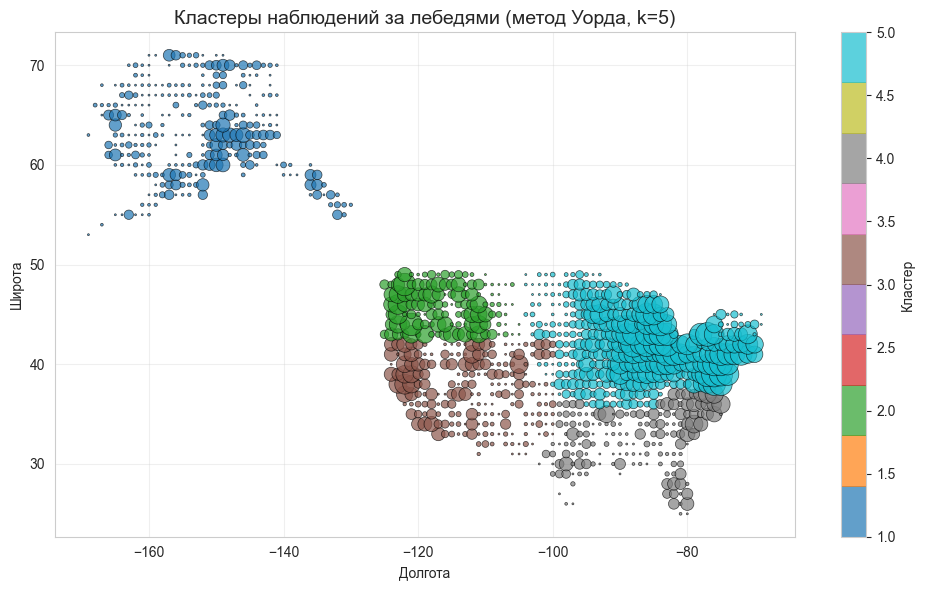

In [55]:
# Строим карту кластеров (размер точки = количество наблюдений)

# Создаем фигуру
plt.figure(figsize=(10, 6))

# Рисуем точки, размер зависит от count, цвет от cluster
scatter = plt.scatter(
    cells['decimal_longitude'], 
    cells['decimal_latitude'],
    c=cells['cluster'],           # цвет по кластеру
    s=cells['count'] * 2,         # размер по количеству наблюдений
    cmap='tab10',                 # цветовая палитра
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Кластеры наблюдений за лебедями (метод Уорда, k=5)', fontsize=14)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.grid(True, alpha=0.3)

# Добавляем легенду
plt.colorbar(scatter, label='Кластер')
plt.tight_layout()
plt.show()

Анализ карты

Кластеры имеют выраженную географическую структуру. При этом самый обособленный кластер - кластер 1, а остальные четыре располагаются ближе друг к другу и частично соприкасаются.

Кластер 1 наиболее обособленный - это самая заметная особенность карты. Кластер практически не пересекается с другими группами и пространственно отделён от них.

Кластер 2 - отдельная северная группа. Группа достаточно компактная, особенно по широте. Она отделена от кластера 1 и при этом имеет достаточно чёткую границу с расположенными ниже наблюдениями кластера 3. Это самостоятельный пространственный сегмент.

Кластер 3 - переходная центральная группа. Здесь уже наблюдается большая неоднородность: кластер вытянут по пространству и частично соседствует с кластерами 2 и 5, поэтому его границы выглядят менее чёткими, чем у кластера 1.

Кластер 4 - южная часть основной группы. Это самая южная часть основной совокупности. При этом кластер довольно хорошо отделяется от кластера 2, но имеет пространственное соседство с кластером 5.

Кластер 5 - самая крупная и наиболее протяжённая группа. Это визуально наиболее крупный и пространственно протяжённый кластер. Он частично перекрывается по координатам с кластерами 3 и 4. 

Кластер 5 имеет наибольший вес (14 153 наблюдения) и крупные точки на карте. Это указывает на то, что именно этот регион является основным местом концентрации зафиксированных наблюдений.

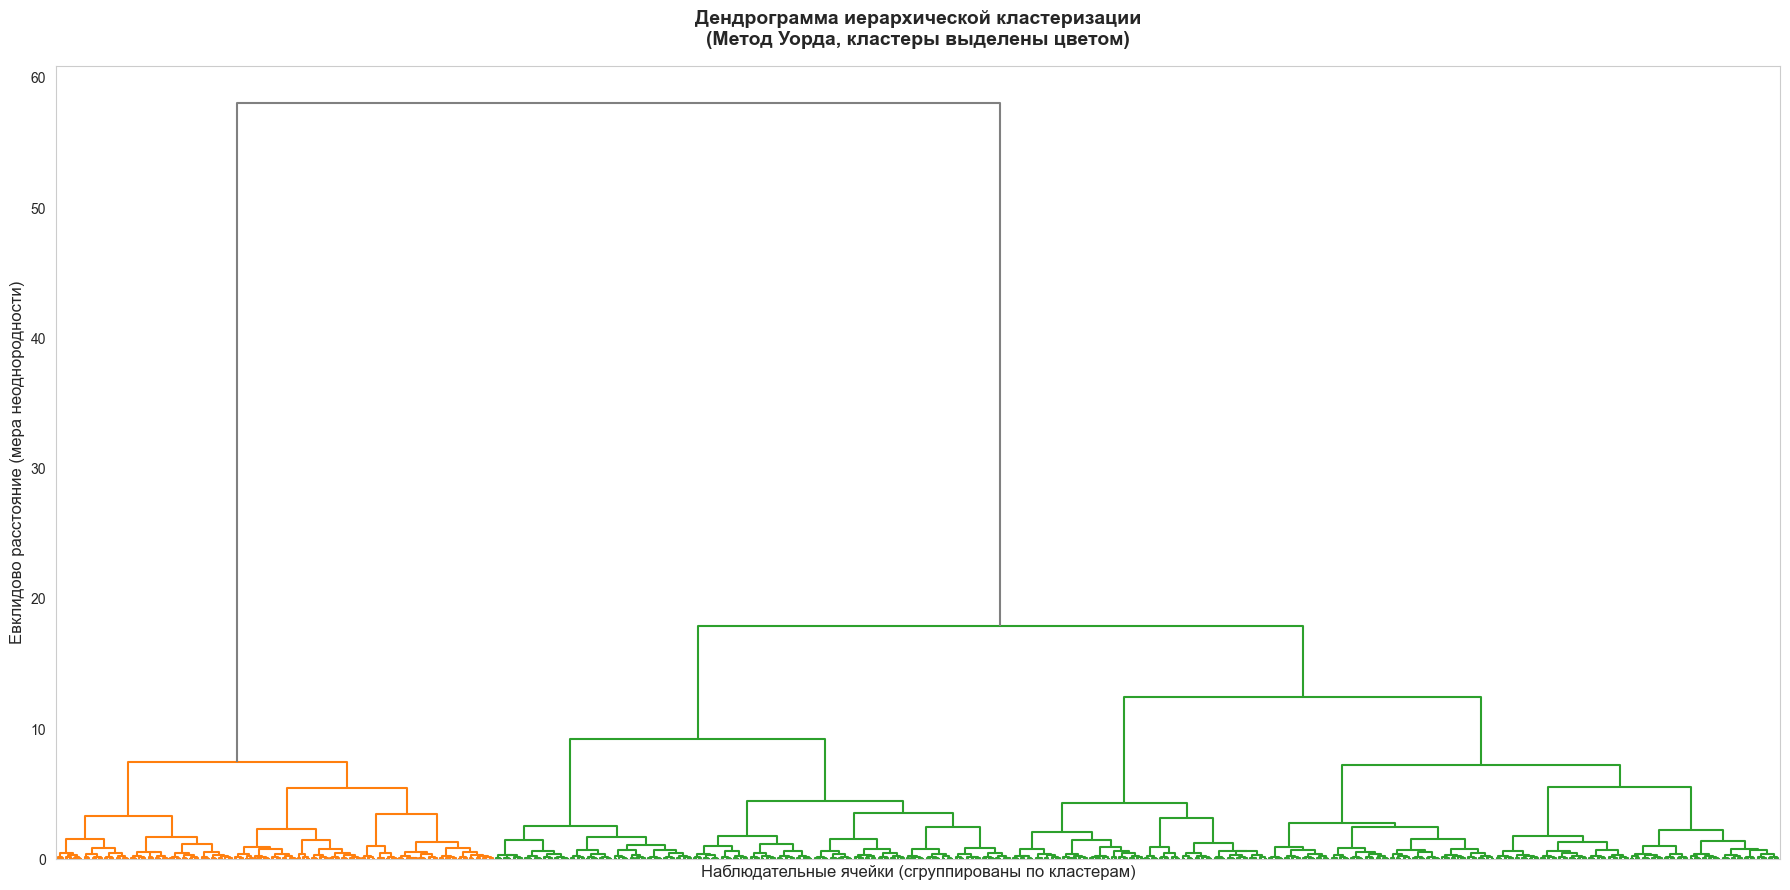

In [56]:
# Дендрограмма кластеризации

# Размер фигуры
plt.figure(figsize=(18, 9))

# Строим дендрограмму с раскраской кластеров
dendrogram(
    linkage_matrix,
    no_labels=True,              # Убираем подписи индексов
    color_threshold=18,          # Порог раскраски (примерно на уровне разделения на 5 кластеров)
    above_threshold_color='gray' # Ветви выше порога - серые
)

plt.title('Дендрограмма иерархической кластеризации\n(Метод Уорда, кластеры выделены цветом)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Наблюдательные ячейки (сгруппированы по кластерам)', fontsize=12)
plt.ylabel('Евклидово расстояние (мера неоднородности)', fontsize=12)

# Добавляем горизонтальную линию на уровне разделения кластеров
#plt.axhline(y=8, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Уровень разделения (k=5)')
#plt.legend(loc='upper right', fontsize=10)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

По дендрограмме мы можем проверить, насколько естественно выглядит разбиение на 5 кластеров. Что мы видим на графике:

- Левая группа наблюдений существенно отличается от основной массы объектов по используемым для кластеризации признакам. Это, вероятно, один из наиболее хорошо выраженных кластеров.
- Внутри правой части наблюдений есть несколько подгрупп, которые между собой отличаются, но не настолько сильно, как левая группа отличается от остальных.
- То есть одна группа отделена от остальных очень сильно, несколько кластеров внутри основной массы разделяются менее выраженно, поэтому не все 5 кластеров имеют одинаково чёткую границу.
  
Дендрограмма скорее показывает один очень хорошо выраженный кластер и несколько более близких между собой подгрупп. Выбранное разбиение на 5 кластеров позволяет детализировать эту структуру, однако границы между некоторыми кластерами менее выражены, чем граница наиболее обособленной группы.

При анализе данных этого проекта нужно помнить, что число наблюдений не равно числу лебедей, а равно числу случаев, когда на этой точке в это время оказался человек, способный зафиксировать наблюдение («человек с биноклем/смартфоном»). 

Аналитические гипотезы на основе этих результатов (что можно проверить дальше или на перспективу развития проекта):

- Гипотеза 1: Смещение выборки в пользу густонаселенных регионов (Observer Bias)
Суть: Огромное число наблюдений в Кластере 5 обусловлено не только реальной численностью лебедей, но и высокой плотностью населения, наличием национальных парков и активностью сообществ орнитологов (например, проекты типа eBird).
Как проверить: Если нормализовать количество наблюдений на численность населения штата или количество зарегистрированных пользователей-наблюдателей, «вес» Кластеров 1 (Аляска) и 2 (Тихоокеанский С-З) может значительно вырасти в относительном выражении.

- Гипотеза 2: Кластер 3 - это строго сезонный «транзитный хаб»
Суть: Поскольку это переходная зона (Западный внутренний регион, включая Большое Соленое озеро), наблюдения здесь должны быть резко привязаны к месяцам миграции (март-апрель и сентябрь-октябрь).
Как проверить: Построить распределение period_type (Зимовка/Гнездование) внутри Кластера 3. Ожидается аномально высокая доля наблюдений, которые не попадают ни в зимовку, ни в гнездование (то есть в межсезонье), в отличие от Кластеров 1 и 4.

- Гипотеза 3: Влияние изменения климата на смещение ареалов (используем столбец time_period)
Суть: Из-за потепления зимы становятся мягче, и лебедям не нужно улетать так далеко на юг.
Как проверить: Сравнить среднюю широту (decimal_latitude) наблюдений в период 1_1980-1988 и 5_2016-2023. Гипотеза подтвердится, если средняя широта зимних наблюдений (period_type=1) в последние годы статистически значимо сдвинулась на север.

- Гипотеза 4: Температурный стресс как ограничивающий фактор
Суть: В Кластере 1 (Аляска) температура 8.16°C является максимально комфортной для гнездования. Любые аномалии (слишком тепло или слишком холодно) в этом узком диапазоне могут резко снижать количество успешных наблюдений (выведения птенцов).

## 16. Описательная статистика по кластерам

> TODO: выведите среднюю широту, температуру и число записей
> по каждому кластеру.

In [57]:
# Ваш код здесь

# Сделано выше перед картой (мне кажется, там она логичнее).

## 17. Линейная регрессия по кластерам

> TODO: для каждого кластера постройте тренд широты по годам
> и выведите `slope`, `R²`, `p-value`.

Проведём анализ смещения ареала обитания (Species Range Shift Analysis) для проверки гипотезы 3 о влиянии изменения климата на миграцию лебедей. Будем строить регрессию отдельно для зимовки и отдельно для гнездования. Смешивать зимние и летние данные нельзя, иначе получится ложный тренд: он отразит не реальное перемещение птиц, а то, что от года к году менялось соотношение количества зимних и летних наблюдений

In [58]:
# Фильтруем данные - оставляем только нужные столбцы
df_reg = data_merged[['year', 'decimal_latitude', 'period_type']]

# Словарь для вывода
season_names = {1: 'Зимовка', 2: 'Гнездование'}

# Строим регрессию отдельно для каждого сезона
for period in [1, 2]:
    subset = df_reg[df_reg['period_type'] == period]
    
    # Считаем регрессию
    slope, intercept, r_value, p_value, std_err = linregress(subset['year'], subset['decimal_latitude'])
    
    # Определяем направление тренда
    if slope > 0:
        direction = "смещается на СЕВЕР (к полюсу) ⬆️"
    elif slope < 0:
        direction = "смещается на ЮГ ⬇️"
    else:
        direction = "тренд отсутствует ️➖"
        
    # Определяем значимость
    significance = "ЗНАЧИМ" if p_value < 0.05 else "НЕ ЗНАЧИМ"
    
    # Считаем смещение за весь период наблюдений (для наглядности)
    years_span = subset['year'].max() - subset['year'].min()
    total_shift_km = slope * years_span * 111 # 1 градус широты ≈ 111 км
    
    print(f"Сезон: {season_names[period]}")
    print(f"Наклон (slope): {slope:.5f} град/год")
    print(f"p-value: {p_value:.4f} ({significance})")
    print(f"R²: {r_value**2:.4f}")
    print(f"Вывод: Ареал {direction}")
    print(f"Общее смещение за {years_span} лет: ≈ {total_shift_km:.1f} км\n")

Сезон: Зимовка
Наклон (slope): 0.00723 град/год
p-value: 0.0339 (ЗНАЧИМ)
R²: 0.0003
Вывод: Ареал смещается на СЕВЕР (к полюсу) ⬆️
Общее смещение за 43 лет: ≈ 34.5 км

Сезон: Гнездование
Наклон (slope): -0.04151 град/год
p-value: 0.0000 (ЗНАЧИМ)
R²: 0.0018
Вывод: Ареал смещается на ЮГ ⬇️
Общее смещение за 43 лет: ≈ -198.1 км



Результаты показали разнонаправленные тренды для разных сезонов:

- Зимовка: Выявлен статистически значимый тренд на смещение ареала зимовки на север (в среднем на ~34 км за 43 года, p=0.034). Это согласуется с климатическими моделями: более мягкие зимы позволяют птицам останавливаться в более высоких широтах.
  
- Гнездование: Выявлен высокозначимый тренд на смещение наблюдений на юг (~198 км за 43 года, p<0.001).

Сдвиг при гнездовании может быть гипотетически рассмотрен не как биологическая миграция популяции на юг, а как проявление эффекта, который мы упомянули в гипотезах выше - эффекта смещения наблюдателя (observer bias). Это эффект "гражданской науки" (Citizen Science Bias): В 1980-х и 1990-х годах данные по гнездованию часто собирались в ходе целевых, хорошо финансируемых научных экспедиций в труднодоступные северные регионы (Аляска, северные штаты). В последние 10-15 лет взрывной рост получили платформы вроде eBird, где данные вносят любители. Любители живут в густонаселенных штатах (Миннесота, Мичиган, Монтана - наши Кластеры 5 и 2), а не на Аляске. Поэтому наблюдения смещаются на юг, даже если сами птицы гнездятся там же. Таким образом, регрессия отражает изменение географии сбора данных, а не обязательно изменение географии гнездования птиц.

Следующим шагом исследования можно проверить эти тренды внутри конкретных кластеров. Построим график трендов средней широты по годам с линией регрессии для Кластера 5 (Средний Запад и Восточное побережье). В нем 14 153 наблюдения (более 50% всех данных). Линия регрессии, построенная на таком объеме, будет статистически самой надежной и визуально самой четкой.
Именно для этого кластера мы ранее видели самые интересные и разнонаправленные тренды (зимой смещение на север, летом - на юг).

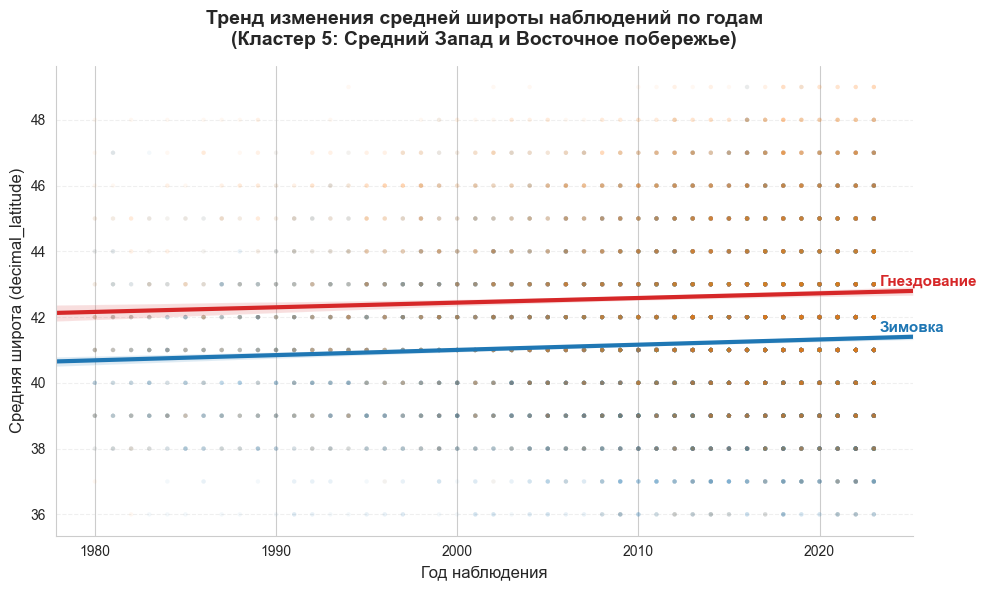

In [59]:
# Строим график тренда средней широты по годам (для Кластера 5)

# Создаем понятные названия для легенды
data_merged['Сезон'] = data_merged['period_type'].map({1: 'Зимовка', 2: 'Гнездование'})

# Фильтруем данные — берем только Кластер 5
df_trend = data_merged[data_merged['cluster'] == 5].copy()

# Размер фигуры
plt.figure(figsize=(10, 6))

# Цвета
palette = {'Зимовка': '#1f77b4', 'Гнездование': '#d62728'}

# Рисуем scatter + regress для каждого сезона отдельно
for season, color in palette.items():
    df_s = df_trend[df_trend['Сезон'] == season]
    if len(df_s) < 2:
        continue

    sns.regplot(
        data=df_s,
        x='year',
        y='decimal_latitude',
        scatter_kws={'alpha': 0.05, 's': 10, 'edgecolors': 'none'},
        line_kws={'linewidth': 3, 'color': color},
        ci=95,
        label=season,
        truncate=False
    )

# Подписи рядом с концами линий регрессии
for season, color in palette.items():
    df_s = df_trend[df_trend['Сезон'] == season]
    if len(df_s) < 2:
        continue

    # Считаем линию регрессии вручную, чтобы получить y на конце линии
    x = df_s['year'].values
    y = df_s['decimal_latitude'].values
    coeffs = np.polyfit(x, y, 1)  # [наклон, сдвиг]

    x_max = x.max()
    y_pred = np.polyval(coeffs, x_max)  # предсказанное y на максимальном году

    # Небольшой вертикальный сдвиг, чтобы подписи не слипались
    offset = 0.3 if season == 'Гнездование' else 0.3

    plt.text(
        x_max + 0.3, y_pred + offset,
        season,
        color=color,
        fontsize=11,
        fontweight='bold',
        va='center'
    )

# Оформление графика
plt.title(
    'Тренд изменения средней широты наблюдений по годам\n(Кластер 5: Средний Запад и Восточное побережье)',
    fontsize=14, fontweight='bold', pad=15
)
plt.xlabel('Год наблюдения', fontsize=12)
plt.ylabel('Средняя широта (decimal_latitude)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
sns.despine()

plt.tight_layout()
plt.show()

Наблюдается положительный тренд смещения ареала на север для обоих сезонов:

- Зимовка: средняя широта увеличилась с 42.2° до 42.7° за 43 года (55 км к северу). Это согласуется с гипотезой о смягчении зимнего климата: лебеди могут оставаться в более высоких широтах, не мигрируя на крайний юг.

- Гнездование: средняя широта увеличилась с 40.7° до 41.3° за 43 года (66 км к северу).

Важный инсайт: этот результат контрастирует с анализом по всему датасету, где для Гнездования был выявлен отрицательный тренд (смещение на юг на 198 км). 

Тренд полностью меняет направление при переходе от агрегированных данных к данным внутри одного кластера. Это может означать, что общий тренд для Гнездования формируется не Кластером 5 (хотя он содержит >50% наблюдений), а другими кластерами, которые имеют сильный отрицательный тренд и «перевешивают» результат. Или присутствует влияние на данные другого фактора.

Зимовка ведёт себя согласованно: в общем датасете (+34.5 км), и в Кластере 5 (+55 км) тренд положительный (на север). Направление совпадает, но величина смещения в Кластере 5 больше. Это говорит о том, что зимний тренд более устойчив и не зависит так сильно от структуры данных.

Очень низкий R² во всех моделях: общий датасет: R² = 0.0003 (зима) и 0.0018 (лето). Это означает, что год объясняет менее 0.2% вариации широты. Тренд статистически значим (p < 0.05), но крайне слаб по силе. Основные факторы, определяющие широту наблюдения - это, судя по всему, не год, а другие переменные (кластер, сезон, конкретный штат).

Разная скорость смещения внутри Кластера 5:
- Зимовка: +0.5° за 43 года (~55 км)
- Гнездование: +0.6° за 43 года (~66 км). Летнее смещение происходит чуть быстрее, чем зимнее, хотя оба направлены на север.

Что можно проверить дальше (или в перспективе развития проекта): 

1. Построить аналогичные графики для остальных кластеров (1, 2, 3, 4):
Это самый очевидный и важный следующий шаг. Особенно интересен Кластер 1 - судя по контрасту в общем тренде Гнездования, именно он (или группа кластеров) может давать сильный отрицательный тренд. Если построить графики для всех 5 кластеров рядом, станет видно, какой из них «тянет» общий результат в сторону юга.

2. Посчитать регрессию внутри каждого кластера отдельно:
Сравнить slope, p-value и R² для зимовки и гнездования по каждому из 5 кластеров. Это даст полную картину:
В каких кластерах тренд значим, а в каких - нет?
Где R² выше (то есть где год лучше объясняет вариацию широты)?
Есть ли кластеры, где тренд противоположен Кластеру 5?

3. Проверить, как меняется R² при анализе по кластерам:
Возможно, внутри одного кластера (где географический разброс меньше) год объясняет бо́льшую долю вариации широты, чем в общем датасете. Это было бы хорошим аргументом в пользу кластерного подхода.

4. Проверить динамику количества наблюдений по годам внутри Кластера 5:
Если число наблюдений резко выросло в определённый период (например, после 2010 года), это могло сместить линию регрессии. Стоит построить график «количество наблюдений vs год» и посмотреть, нет ли скачков.

5. Проверить, нет ли «переломных» годов:
Возможно, тренд нелинейный: например, до 2000 года широта стабильна, а после - начинает расти. Это можно проверить, разбив период на два подпериода и посчитав регрессию для каждого.

6. Добавить температуру как контрольную переменную:
Поскольку имеется гипотеза о смягчении климата, можно проверить: действительно ли средняя температура в Кластере 5 растёт по годам? Если да - это усилит климатическую интерпретацию тренда широты.

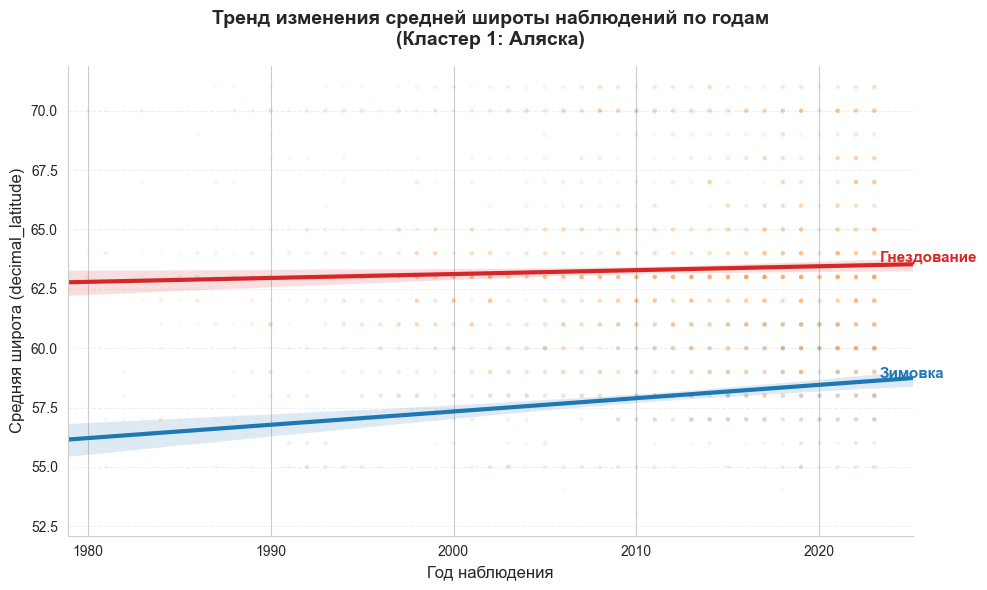

In [60]:
# Строим график тренда средней широты по годам (для Кластера 1)

# Фильтруем данные — берем только Кластер 1
df_trend = data_merged[data_merged['cluster'] == 1].copy()

# Размер фигуры
plt.figure(figsize=(10, 6))

# Цвета
palette = {'Зимовка': '#1f77b4', 'Гнездование': '#d62728'}

# Рисуем scatter + regress для каждого сезона отдельно
for season, color in palette.items():
    df_s = df_trend[df_trend['Сезон'] == season]
    if len(df_s) < 2:
        continue

    sns.regplot(
        data=df_s,
        x='year',
        y='decimal_latitude',
        scatter_kws={'alpha': 0.05, 's': 10, 'edgecolors': 'none'},
        line_kws={'linewidth': 3, 'color': color},
        ci=95,
        label=season,
        truncate=False
    )

# Подписи рядом с концами линий регрессии
for season, color in palette.items():
    df_s = df_trend[df_trend['Сезон'] == season]
    if len(df_s) < 2:
        continue

    # Считаем линию регрессии вручную, чтобы получить y на конце линии
    x = df_s['year'].values
    y = df_s['decimal_latitude'].values
    coeffs = np.polyfit(x, y, 1)  # [наклон, сдвиг]

    x_max = x.max()
    y_pred = np.polyval(coeffs, x_max)  # предсказанное y на максимальном году

    # Небольшой вертикальный сдвиг, чтобы подписи не слипались
    offset = 0.3 if season == 'Гнездование' else 0.3

    plt.text(
        x_max + 0.3, y_pred + offset,
        season,
        color=color,
        fontsize=11,
        fontweight='bold',
        va='center'
    )

# Оформление графика
plt.title(
    'Тренд изменения средней широты наблюдений по годам\n(Кластер 1: Аляска)',
    fontsize=14, fontweight='bold', pad=15
)
plt.xlabel('Год наблюдения', fontsize=12)
plt.ylabel('Средняя широта (decimal_latitude)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
sns.despine()

plt.tight_layout()
plt.show()

Гипотеза, что Кластер 1 может давать сильный отрицательный тренд в общем тренде Гнездования, не подтверждается. Наоборот, он показывает положительный тренд, согласующийся с Кластером 5.

In [61]:
# Рассчитаем тренды смещения широты для всех кластеров по сезонам

# Фильтруем данные - оставляем только нужные столбцы
df_reg = data_merged[['year', 'decimal_latitude', 'period_type', 'cluster']]

# Получаем уникальные кластеры и сортируем их для аккуратного вывода
unique_clusters = sorted(df_reg['cluster'].unique())

for cluster in unique_clusters:
    print(f"\nКЛАСТЕР {cluster}")

    for period in [1, 2]:
        # Фильтруем по кластеру и сезону
        subset = df_reg[(df_reg['cluster'] == cluster) & (df_reg['period_type'] == period)]
        
        # Проверка: для линейной регрессии нужно минимум 2 точки
        if len(subset) < 2:
            print(f"Сезон: {season_names[period]}")
            print("Недостаточно данных для построения тренда.\n")
            continue
        
        # Считаем регрессию
        slope, intercept, r_value, p_value, std_err = linregress(subset['year'], subset['decimal_latitude'])
        
        # Определяем направление тренда
        if slope > 0:
            direction = "смещается на СЕВЕР (к полюсу) ⬆️"
        elif slope < 0:
            direction = "смещается на ЮГ ⬇️"
        else:
            direction = "тренд отсутствует ➖"
            
        # Определяем значимость
        significance = "ЗНАЧИМ" if p_value < 0.05 else "НЕ ЗНАЧИМ"
        
        # Считаем смещение за весь период наблюдений (для наглядности)
        years_span = subset['year'].max() - subset['year'].min()
        total_shift_km = slope * years_span * 111 # 1 градус широты ≈ 111 км
        
        print(f"Сезон: {season_names[period]}")
        print(f"Наклон (slope) : {slope:.5f} град/год")
        print(f"p-value        : {p_value} ({significance})")
        print(f"R²             : {r_value**2:.4f}")
        print(f"Вывод          : Ареал {direction}")
        print(f"Смещение за {years_span} лет : ≈ {total_shift_km:.1f} км\n")


КЛАСТЕР 1
Сезон: Зимовка
Наклон (slope) : 0.05606 град/год
p-value        : 1.2477377037778564e-06 (ЗНАЧИМ)
R²             : 0.0788
Вывод          : Ареал смещается на СЕВЕР (к полюсу) ⬆️
Смещение за 42 лет : ≈ 261.4 км

Сезон: Гнездование
Наклон (slope) : 0.01644 град/год
p-value        : 0.039030099563354834 (ЗНАЧИМ)
R²             : 0.0018
Вывод          : Ареал смещается на СЕВЕР (к полюсу) ⬆️
Смещение за 43 лет : ≈ 78.5 км


КЛАСТЕР 2
Сезон: Зимовка
Наклон (slope) : 0.00344 град/год
p-value        : 0.29459244290617126 (НЕ ЗНАЧИМ)
R²             : 0.0004
Вывод          : Ареал смещается на СЕВЕР (к полюсу) ⬆️
Смещение за 43 лет : ≈ 16.4 км

Сезон: Гнездование
Наклон (slope) : 0.02786 град/год
p-value        : 1.8770179121276185e-08 (ЗНАЧИМ)
R²             : 0.0318
Вывод          : Ареал смещается на СЕВЕР (к полюсу) ⬆️
Смещение за 43 лет : ≈ 133.0 км


КЛАСТЕР 3
Сезон: Зимовка
Наклон (slope) : 0.00043 град/год
p-value        : 0.9264340298390976 (НЕ ЗНАЧИМ)
R²             : 0.000

- Кластер 5 (Средний Запад и Восток, самый крупный): и зимовка, и гнездование значимо смещаются на СЕВЕР (+75 км и +67 км).

- Кластер 1 (Аляска) и Кластер 2 (Тихоокеанский С-З): гнездование также значимо смещается на СЕВЕР (+78 км и +133 км).

- Кластер 4 (Южное побережье) - ГЛАВНЫЙ ВИНОВНИК ПАРАДОКСА: и зимовка, и гнездование значимо смещаются на ЮГ (-173 км и -219 км). Именно этот кластер своим сильным отрицательным наклоном "перетягивал" общую среднюю линию всего датасета вниз, создавая иллюзию глобального смещения на юг.
Гипотеза: Это классическое смещение наблюдателя (observer bias). Скорее всего, в последние годы в базу данных (например, через eBird) хлынул поток новых наблюдений из южных штатов (Флорида, Техас, Каролины), которых раньше там просто фиксировали меньше. Это не птицы улетают на юг, это данные "переехали" на юг.

- Кластер 3 (Западный внутренний):
Тренды незначимы (p > 0.05). Это статистический шум, здесь нет четкого направленного движения.

## 18. Корреляционный анализ

> TODO: посчитайте корреляцию:
> - широта vs температура (в целом и по сезонам);
> - широта vs плотность населения.

In [62]:
# Рассчитываем корреляцию широта vs температура (в целом)
r_p_1, p_p_1 = pearsonr(data_merged['decimal_latitude'], data_merged['avg_temp_c'])
rho_s_1, p_s_1 = spearmanr(data_merged['decimal_latitude'], data_merged['avg_temp_c'])

print("Корреляция широта vs температура (в целом):")
print(f"Пирсон:  r = {r_p_1:.3f}, p = {p_p_1}")
print(f"Спирмен: ρ = {rho_s_1:.3f}, p = {p_s_1}\n")

Корреляция широта vs температура (в целом):
Пирсон:  r = -0.025, p = 4.238737757349597e-05
Спирмен: ρ = -0.089, p = 1.9181423934340445e-47



Очень слабая сила связи (r=−0.025) - это происходит потому, что мы посчитали корреляцию по всему датасету сразу, смешав зиму и лето. Летом лебеди находятся на высокой широте (Аляска, ~65°), и там тепло (+10...+15°C). Зимой лебеди находятся на низкой широте (Флорида, Мэриленд, ~30-40°), и там тоже относительно тепло (+5...+10°C).

Когда мы смешиваем эти два состояния, общая картина "размывается". Поэтому необходимо посчитать корреляцию отдельно по сезонам:

In [63]:
# Рассчитываем корреляцию широта vs температура (по сезонам)
season_names = {1: "Зимовка", 2: "Гнездование"}

for season in [1, 2]:
    # Берем подвыборку только для текущего сезона
    subset = data_merged[data_merged['period_type'] == season]
    
    r_p, p_p = pearsonr(subset['decimal_latitude'], subset['avg_temp_c'])
    rho_s, p_s = spearmanr(subset['decimal_latitude'], subset['avg_temp_c'])
    
    print(f"Корреляция широта vs температура ({season_names[season]}):")
    print(f"Пирсон:  r = {r_p:.3f}, p = {p_p}")
    print(f"Спирмен: ρ = {rho_s:.3f}, p = {p_s}")

Корреляция широта vs температура (Зимовка):
Пирсон:  r = -0.698, p = 0.0
Спирмен: ρ = -0.637, p = 0.0
Корреляция широта vs температура (Гнездование):
Пирсон:  r = -0.904, p = 0.0
Спирмен: ρ = -0.850, p = 0.0


Как только мы разделили данные по сезонам (устранив смешивающий фактор), выявились сильные статистически значимые отрицательные связи (p<0.001):

1. В период гнездования наблюдается очень высокая линейная зависимость (r=−0.904). Это биологически обосновано: места летнего гнездования строго привязаны к высоким широтам, где температурный градиент имеет четкий и предсказуемый характер.

2. В период зимовки связь также сильна, но несколько ниже (r=−0.698). Это объясняется тем, что зимой распределение лебедей диктуется не столько абсолютной широтой, сколько наличием локальных незамерзающих водоемов и микроклиматическими особенностями регионов, что увеличивает разброс температурных значений при одной и той же широте.

In [64]:
# Присоединяем к основной таблице данные о плотности населения
df_analysis = data_merged.merge(df_US_CA[['state_province', 'density_per']], on='state_province', how='left')
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26418 entries, 0 to 26417
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   gbif_id            26418 non-null  int64         
 1   recorded_by        26418 non-null  object        
 2   event_date         26418 non-null  datetime64[ns]
 3   year               26418 non-null  int64         
 4   month              26418 non-null  int64         
 5   day                26418 non-null  int64         
 6   country_code       26418 non-null  object        
 7   state_province     26418 non-null  object        
 8   decimal_latitude   26418 non-null  float64       
 9   decimal_longitude  26418 non-null  float64       
 10  species            26418 non-null  object        
 11  period_type        26418 non-null  float64       
 12  time_period        26418 non-null  object        
 13  state              26413 non-null  object        
 14  avg_te

In [65]:
# Рассчитываем корреляцию широта vs плотность населения
r_p_1, p_p_1 = pearsonr(df_analysis['decimal_latitude'], df_analysis['density_per'])
rho_s_1, p_s_1 = spearmanr(df_analysis['decimal_latitude'], df_analysis['density_per'])

print("Корреляция широта vs плотность населения:")
print(f"Пирсон:  r = {r_p_1:.3f}, p = {p_p_1}")
print(f"Спирмен: ρ = {rho_s_1:.3f}, p = {p_s_1}\n")

Корреляция широта vs плотность населения:
Пирсон:  r = -0.266, p = 0.0
Спирмен: ρ = -0.499, p = 0.0



Слабая линейная (Пирсон: r=−0.266) и умеренная монотонная (Спирмен: ρ=−0.499) отрицательная связь (p<0.001 для обоих).

Значительное расхождение между коэффициентами указывает на нелинейный характер распределения плотности населения (влияние выбросов): наименьшая плотность характерна для крайних северных широт, в то время как максимальная плотность сосредоточена как на юге, так и в отдельных штатах средних широт (Восточное побережье).

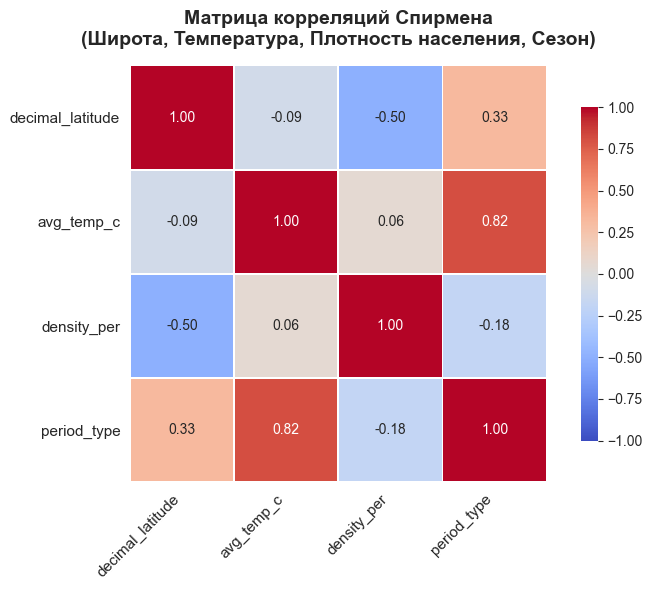

In [66]:
# Построим тепловую карту корреляций

# Выбираем числовые столбцы для анализа. 
# Добавляем period_type, так как сезон (1 или 2) тоже числовой и сильно влияет на широту и температуру!
cols_to_analyze = ['decimal_latitude', 'avg_temp_c', 'density_per', 'period_type']

# Считаем матрицу корреляций Пирсона
corr_matrix = df_analysis[cols_to_analyze].corr(method='spearman') # Как мы выяснили ранее, для пары 'широта-плотность' линейная модель не идеальна

# 3. Настраиваем визуализацию
plt.figure(figsize=(8, 6))

# Рисуем тепловую карту
heatmap = sns.heatmap(
    corr_matrix, 
    annot=True,          # Показываем значения коэффициентов на карте
    fmt=".2f",           # Округляем до 2 знаков после запятой
    cmap='coolwarm',     # Цветовая схема: синий (отрицательная), белый (0), красный (положительная)
    vmin=-1, vmax=1,     # Фиксируем шкалу от -1 до 1 для корректного отображения цветов
    linewidths=.5,       # Тонкие линии между ячейками для читаемости
    square=True,         # Делаем ячейки квадратными
    cbar_kws={"shrink": .8} # Немного уменьшаем легенду справа
)

# Оформляем график
plt.title('Матрица корреляций Спирмена\n(Широта, Температура, Плотность населения, Сезон)', 
          fontsize=14, fontweight='bold', pad=15)

# Делаем подписи осей горизонтальными и читаемыми
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

Тепловая карта наглядно демонстрирует структуру взаимосвязей между ключевыми переменными:

1. Наибольшая корреляция наблюдается между температурой и сезоном (ρ = 0.82), что подтверждает: температурные условия в местах наблюдений определяются в первую очередь временем года, а не географией.
  
2. Умеренная положительная связь между широтой и сезоном (ρ = 0.33) математически фиксирует миграцию лебедей: зимой наблюдения смещены на юг (низкие широты), летом - на север (высокие широты).

3. При смешивании сезонов связь широты и температуры практически исчезает (ρ = -0.09). Как показано ранее, при стратификации по сезонам эта связь становится сильной (до -0.904 летом).

4. Умеренная отрицательная корреляция широты и плотности населения (ρ = -0.50) отражает географическую реальность: наименее заселены крайне северные территории. При этом температура в местах наблюдений практически не связана с плотностью населения (ρ = 0.06).

Для проверки гипотезы о смещении наблюдателя рассчитаем корреляцию количества наблюдений и плотности населения. Если гипотеза верна, мы должны увидеть сильную положительную корреляцию: чем выше плотность населения в штате, тем больше там зафиксировано наблюдений лебедей (потому что там просто больше людей с биноклями и смартфонами).

In [67]:
# Считаем количество наблюдений лебедей по каждому штату из основного датасета
state_counts = data_merged['state_province'].value_counts().reset_index()
state_counts.columns = ['state_province', 'observation_count']

# Объединяем две таблицы по названию штата
# Используем inner join, чтобы оставить только те штаты, где есть и лебеди, и данные о плотности
bias_df = state_counts.merge(df_US_CA[['state_province', 'density_per']], on='state_province', how='inner')

print(f"Для расчёта используется {len(bias_df)} штатов/провинций.\n")

# Считаем корреляции
r_p, p_p = pearsonr(bias_df['observation_count'], bias_df['density_per'])
rho_s, p_s = spearmanr(bias_df['observation_count'], bias_df['density_per'])

print("Корреляция количество наблюдений vs плотность населения")
print(f"Пирсон:  r = {r_p:.3f}, p = {p_p}")
print(f"Спирмен: ρ = {rho_s:.3f}, p = {p_s}")

Для расчёта используется 50 штатов/провинций.

Корреляция количество наблюдений vs плотность населения
Пирсон:  r = -0.144, p = 0.319983460652851
Спирмен: ρ = 0.085, p = 0.555526740275391


Статистически значимой связи не выявлено (Пирсон: r=−0.144,p=0.32; Спирмен: ρ=0.085,p=0.56).

Отсутствие корреляции указывает на то, что географическое распределение зафиксированных наблюдений не дублирует карту расселения людей. Это свидетельствует о высоком качестве данных: наблюдения привязаны к специфическим природным биотопам (водно-болотные угодья, крупные озера, заповедные зоны), а не к местам компактного проживания человека. Волонтеры и исследователи целенаправленно посещают места обитания птиц, что минимизирует эффект "смещения наблюдателя" на макроуровне (уровне штата).

<Figure size 1000x500 with 0 Axes>

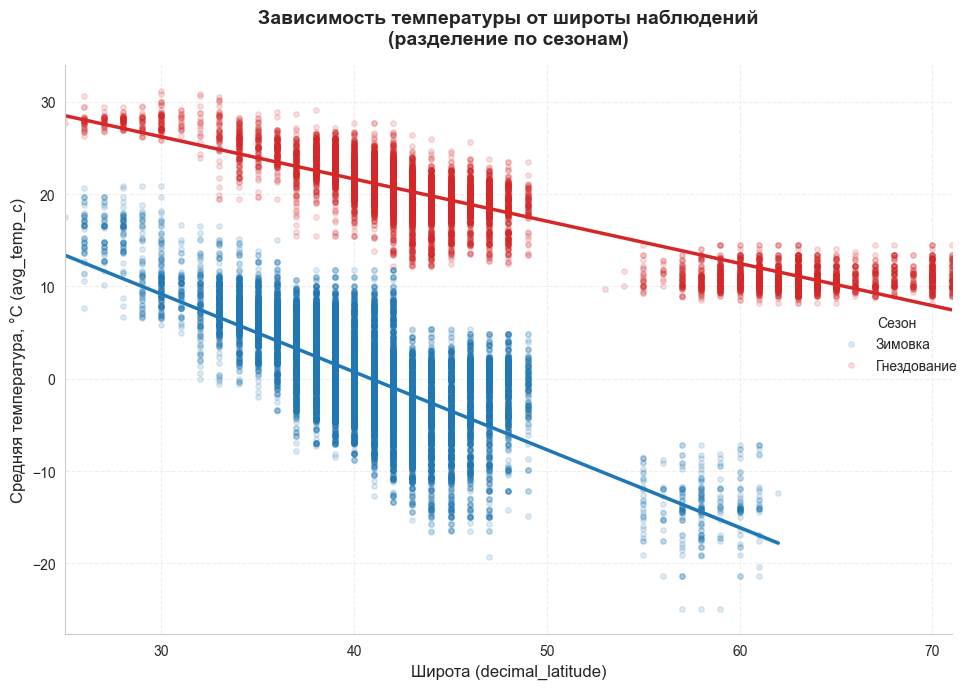

In [68]:
# Построим диаграмму рассеяния широта vs температура с разделением по сезонам

# Размер фигуры
plt.figure(figsize=(10, 5))

# Строим диаграмму рассеяния с линиями регрессии
sns.lmplot(
    data=data_merged,
    x='decimal_latitude',
    y='avg_temp_c',
    hue='Сезон',
    palette={ 'Зимовка': '#1f77b4', 'Гнездование': '#d62728' }, # Синий и Красный
    scatter_kws={'alpha': 0.15, 's': 15}, # Делаем точки полупрозрачными и маленькими, чтобы не сливались в кашу
    line_kws={'linewidth': 2.5},          # Делаем линии тренда жирными и заметными
    height=7,
    aspect=1.2
)

# Оформление графика
plt.title('Зависимость температуры от широты наблюдений\n(разделение по сезонам)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Широта (decimal_latitude)', fontsize=12)
plt.ylabel('Средняя температура, °C (avg_temp_c)', fontsize=12)

# Добавляем сетку
plt.grid(True, alpha=0.3, linestyle='--')

sns.despine() # Убираем верхнюю и правую рамки графика для более чистого вида

plt.tight_layout()
plt.show()

Диаграмма рассеяния наглядно демонстрирует эффект смешивающей переменной (сезонности). При объединении всех наблюдений общая корреляция близка к нулю (r = -0.09), однако стратификация данных выявляет две сильные отрицательные зависимости:

- Период гнездования (красный): наблюдается почти идеальная линейная зависимость (r = -0.904). Места летнего гнездования жестко привязаны к широтному температурному градиенту.

- Период зимовки (синий): зависимость также сильна (r = -0.698), но с большим разбросом значений. Это отражает влияние локальных факторов (близость океана, Гольфстрим, крупные незамерзающие водоемы), которые позволяют лебедям зимовать в более высоких широтах, чем предсказывала бы одна только географическая широта.

- Отсутствие пересечения двух облаков точек по температурной оси подтверждает, что лебеди являются строгими температурными мигрантами, целенаправленно выбирающими места обитания с сезонно-комфортным климатом.

## 19. Сравнение групп (Kruskal-Wallis, Mann-Whitney)

> TODO:
> - сравните виды по широте и температуре;
> - сравните сезоны по широте;
> - проведите попарные сравнения видов.

Географические координаты и температуры в экологии почти никогда не распределены нормально и содержат выбросы, поэтому классические t-тесты или ANOVA здесь дадут ложные результаты. Для таких данных лучше подойдут непараметрические тесты (Краскела-Уоллиса и Манна-Уитни).

In [69]:
# Сравнение видов по широте и температуре

species_list = data_merged['species'].unique()

print(f"Уникальные виды в датасете: {species_list}")

print("Сравнение видов (Краскел-Уоллис):")

# По широте
groups_lat = [data_merged[data_merged['species'] == sp]['decimal_latitude'] for sp in species_list]
stat_lat, p_lat = kruskal(*groups_lat)
print(f"Широта: H = {stat_lat:.2f}, p = {p_lat}")
print(f"Вывод: {'Есть значимые различия' if p_lat < 0.05 else 'Нет значимых различий'} между видами по широте.\n")

# По температуре
groups_temp = [data_merged[data_merged['species'] == sp]['avg_temp_c'] for sp in species_list]
stat_temp, p_temp = kruskal(*groups_temp)
print(f"Температура: H = {stat_temp:.2f}, p = {p_temp}")
print(f"Вывод: {'Есть значимые различия' if p_temp < 0.05 else 'Нет значимых различий'} между видами по температуре.\n")

Уникальные виды в датасете: ['Cygnus olor' 'Cygnus buccinator' 'Cygnus columbianus']
Сравнение видов (Краскел-Уоллис):
Широта: H = 3355.52, p = 0.0
Вывод: Есть значимые различия между видами по широте.

Температура: H = 1423.56, p = 7.55748733960117e-310
Вывод: Есть значимые различия между видами по температуре.



Распределения широты и температуры не одинаковы для трех видов лебедей. Как минимум один вид существенно отличается от остальных.

Три вида не перемешаны на карте случайным образом. Они занимают разные широтные пояса. Это указывает на то, что у каждого вида свой исторически сложившийся географический ареал обитания в Северной Америке.

Виды обитают в принципиально разных термальных условиях. 

In [70]:
# Сравнение сезонов по широте

print("Сравнение сезонов по широте (Манн-Уитни):")

group_winter = data_merged[data_merged['Сезон'] == 'Зимовка']['decimal_latitude']
group_breeding = data_merged[data_merged['Сезон'] == 'Гнездование']['decimal_latitude']

stat_season, p_season = mannwhitneyu(group_winter, group_breeding, alternative='two-sided')

print(f"Зимовка vs Гнездование (широта): U = {stat_season:.0f}, p = {p_season:.4e}")
print(f"Вывод: {'Есть значимые различия' if p_season < 0.05 else 'Нет значимых различий'} в широте наблюдений между сезонами.")

# Для наглядности добавим медианы
print(f"\nМедиана широты Зимовка: {group_winter.median():.2f}°")
print(f"Медиана широты Гнездование: {group_breeding.median():.2f}°")

Сравнение сезонов по широте (Манн-Уитни):
Зимовка vs Гнездование (широта): U = 49002182, p = 0.0000e+00
Вывод: Есть значимые различия в широте наблюдений между сезонами.

Медиана широты Зимовка: 41.00°
Медиана широты Гнездование: 44.00°


Отвергаем нулевую гипотезу: широты зимних и летних наблюдений принадлежат к разным распределениям. Лебеди целенаправленно выбирают более высокие (северные) широты для размножения (гнездования) и смещаются в более низкие (южные) широты для зимовки. Разница в 3 градуса (примерно 330 км) четко очерчивает масштаб их сезонных миграций в рамках изучаемого региона. 

In [71]:
# Попарные сравнения видов (Манн-Уитни) с поправкой Бонферрони (так как сравнения множественные)

print("Попарные сравнения видов (Манн-Уитни с поправкой Бонферрони):")

p_values_lat = []
p_values_temp = []
pairs = []

for sp1, sp2 in combinations(species_list, 2):
    pairs.append(f"{sp1} vs {sp2}")
    
    # Для широты
    g1_lat = data_merged[data_merged['species'] == sp1]['decimal_latitude']
    g2_lat = data_merged[data_merged['species'] == sp2]['decimal_latitude']
    stat, p = mannwhitneyu(g1_lat, g2_lat, alternative='two-sided')
    p_values_lat.append(p)
    
    # Для температуры
    g1_temp = data_merged[data_merged['species'] == sp1]['avg_temp_c']
    g2_temp = data_merged[data_merged['species'] == sp2]['avg_temp_c']
    stat, p = mannwhitneyu(g1_temp, g2_temp, alternative='two-sided')
    p_values_temp.append(p)

# Применяем поправку Бонферрони
reject_lat, p_corrected_lat, _, _ = multipletests(p_values_lat, method='bonferroni')
reject_temp, p_corrected_temp, _, _ = multipletests(p_values_temp, method='bonferroni')

for i, pair in enumerate(pairs):
    print(f"Пара: {pair}")
    print(f"Широта:      p = {p_values_lat[i]:.4e} -> скорр. p = {p_corrected_lat[i]:.4e} ({'ЗНАЧИМО' if reject_lat[i] else 'не значимо'})")
    print(f"Температура: p = {p_values_temp[i]:.4e} -> скорр. p = {p_corrected_temp[i]:.4e} ({'ЗНАЧИМО' if reject_temp[i] else 'не значимо'})")

Попарные сравнения видов (Манн-Уитни с поправкой Бонферрони):
Пара: Cygnus olor vs Cygnus buccinator
Широта:      p = 0.0000e+00 -> скорр. p = 0.0000e+00 (ЗНАЧИМО)
Температура: p = 2.2318e-108 -> скорр. p = 6.6954e-108 (ЗНАЧИМО)
Пара: Cygnus olor vs Cygnus columbianus
Широта:      p = 9.1832e-140 -> скорр. p = 2.7550e-139 (ЗНАЧИМО)
Температура: p = 3.5725e-287 -> скорр. p = 1.0718e-286 (ЗНАЧИМО)
Пара: Cygnus buccinator vs Cygnus columbianus
Широта:      p = 2.7691e-165 -> скорр. p = 8.3073e-165 (ЗНАЧИМО)
Температура: p = 1.1236e-75 -> скорр. p = 3.3708e-75 (ЗНАЧИМО)


Результаты теста подтверждают, что три вида лебедей (Cygnus olor, Cygnus buccinator, Cygnus columbianus) не перемешаны в пространстве случайным образом. Каждый вид занимает свой уникальный географический (широта) и климатический (температура) ареал. 

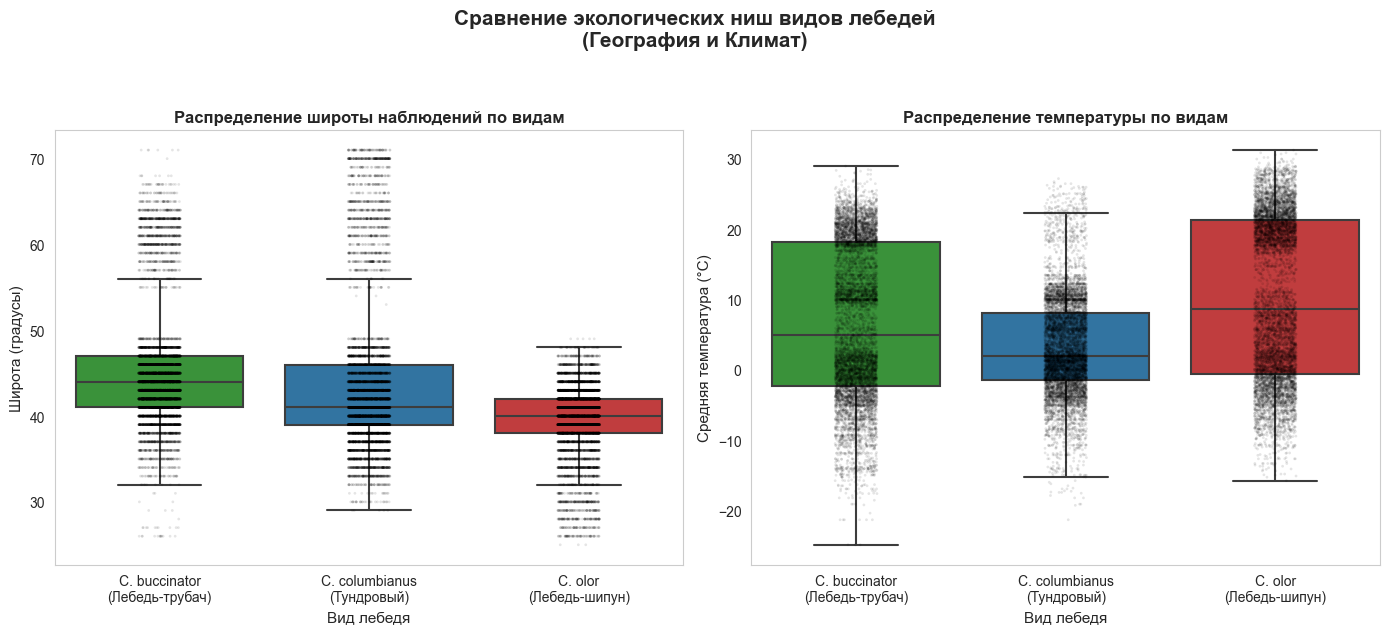

In [72]:
# Построим boxplot (сравнение широты и температуры по видам)

# Определяем порядок видов на графике: от самой высокой медианной широты к самой низкой (Север -> Юг)
median_order = data_merged.groupby('species')['decimal_latitude'].median().sort_values(ascending=False).index

# Создаем русские названия для легенды и осей (опционально, для красоты отчета)
species_names_ru = {
    'Cygnus columbianus': 'C. columbianus\n(Тундровый)',
    'Cygnus buccinator': 'C. buccinator\n(Лебедь-трубач)',
    'Cygnus olor': 'C. olor\n(Лебедь-шипун)'
}
data_merged['species_ru'] = data_merged['species'].map(species_names_ru)

# Настраиваем фигуру с двумя графиками рядом
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Цветовая палитра
palette = {'C. columbianus\n(Тундровый)': '#1f77b4', 
           'C. buccinator\n(Лебедь-трубач)': '#2ca02c', 
           'C. olor\n(Лебедь-шипун)': '#d62728'}

# График А: Широта по видам
sns.boxplot(
    data=data_merged, 
    x='species_ru', 
    y='decimal_latitude', 
    order=median_order.map(species_names_ru), # Применяем порядок
    palette=palette, 
    ax=axes[0],
    showfliers=False # Скрываем выбросы, чтобы не перегружать график
)
# Добавляем точки данных (stripplot) для показа плотности распределения
sns.stripplot(
    data=data_merged, 
    x='species_ru', 
    y='decimal_latitude', 
    order=median_order.map(species_names_ru),
    color='black', 
    size=2, 
    alpha=0.1, 
    ax=axes[0]
)
axes[0].set_title('Распределение широты наблюдений по видам', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Вид лебедя', fontsize=11)
axes[0].set_ylabel('Широта (градусы)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# График Б: Температура по видам
sns.boxplot(
    data=data_merged, 
    x='species_ru', 
    y='avg_temp_c', 
    order=median_order.map(species_names_ru), # Тот же порядок для сопоставимости
    palette=palette, 
    ax=axes[1],
    showfliers=False
)
sns.stripplot(
    data=data_merged, 
    x='species_ru', 
    y='avg_temp_c', 
    order=median_order.map(species_names_ru),
    color='black', 
    size=2, 
    alpha=0.1, 
    ax=axes[1]
)
axes[1].set_title('Распределение температуры по видам', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Вид лебедя', fontsize=11)
axes[1].set_ylabel('Средняя температура (°C)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Сравнение экологических ниш видов лебедей\n(География и Климат)', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

По медианной широте:

- C. buccinator (Лебедь-трубач): медиана ~45° - самый северный
- C. columbianus (Тундровый лебедь): медиана ~42° - промежуточное положение
- C. olor (Лебедь-шипун): медиана ~41° - самый южный
  
По температуре:

- C. columbianus: медиана ~2°C - самый холодный
- C. buccinator: медиана ~5°C - промежуточное положение
- C. olor: медиана ~9°C - самый теплый

Интересный парадокс: C. columbianus - самый "холодный", но не самый "северный": несмотря на то что его медианная широта ниже, чем у C. buccinator, его медианная температура ниже (2°C против 5°C). 

Это может означать, что:

- C. columbianus чаще наблюдается в континентальном климате (холодные зимы в глубине континента)
- C. buccinator чаще наблюдается в прибрежных регионах (Аляска, где климат мягче благодаря океану)

Чтобы углубить анализ, можно:

1. Построить боксплоты отдельно для каждого сезона (Зимовка vs Гнездование). Возможно, в период гнездования C. columbianus всё-таки окажется самым северным.
2. Посмотреть на распределение по кластерам - какой вид доминирует в каждом из 5 кластеров

## 20. Множественная регрессия

> TODO: постройте модель `decimal_latitude ~ year + avg_temp_c + density_per`.
> Выведите коэффициенты, `R²`, `p-value`.

Множественная линейная регрессия (Multiple Linear Regression) позволяет оценить вклад каждого фактора при условии, что все остальные факторы остаются неизменными (принцип ceteris paribus).

In [73]:
# Строим модель decimal_latitude ~ year + avg_temp_c + density_per

# Подготовка данных: берем только нужные столбцы
df_reg = df_analysis[['decimal_latitude', 'year', 'avg_temp_c', 'density_per', 'period_type']]

X_base = df_reg[['year', 'avg_temp_c', 'density_per']]
X_base = sm.add_constant(X_base)  # Добавляем константу (свободный член / intercept)
y = df_reg['decimal_latitude']

model_base = sm.OLS(y, X_base).fit()
print(model_base.summary())

                            OLS Regression Results                            
Dep. Variable:       decimal_latitude   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     683.2
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:33:46   Log-Likelihood:                -90435.
No. Observations:               26418   AIC:                         1.809e+05
Df Residuals:                   26414   BIC:                         1.809e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          98.4121      8.899     11.059      

Построенная модель широта ~ год + температура + плотность_населения статистически значима в целом (F-statistic p < 0.001), объясняя 7.2% дисперсии широты (Adj. R² = 0.072).

Анализ коэффициентов выявил важный методологический инсайт:

- Переменная avg_temp_c оказалась статистически незначимой (p = 0.367). Это классическое проявление парадокса Симпсона: при объединении зимних и летних данных противоположные температурно-широтные градиенты этих сезонов компенсируют друг друга, скрывая реальные взаимосвязи.

- Переменная year показывает значимый отрицательный тренд (coef = -0.0268, p < 0.001), указывая на общее смещение выборки на юг примерно на 3 км в год.

- Переменная density_per значима и отрицательна (p < 0.001), что отражает географическую специфику США: высокая плотность населения сосредоточена в более южных штатах по сравнению с малонаселенными северными территориями.

Следующий шаг - построить модель, добавив сезон:

In [74]:
# Строим улучшенную модель (с контролем сезонности)

# Превращаем сезон в dummy-переменную (0 = Зимовка, 1 = Гнездование)
# drop_first=True оставляет один столбец, чтобы избежать мультиколлинеарности (dummy variable trap)
df_reg_dummies = pd.get_dummies(df_reg, columns=['period_type'], drop_first=True)

# Теперь в X добавляем сезон (столбец будет называться period_type_2.0, где 2.0 - это Гнездование)
X_adv = df_reg_dummies[['year', 'avg_temp_c', 'density_per', 'period_type_2.0']]
X_adv = sm.add_constant(X_adv)

model_adv = sm.OLS(y, X_adv).fit()
print(model_adv.summary())

                            OLS Regression Results                            
Dep. Variable:       decimal_latitude   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                 1.077e+04
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:33:47   Log-Likelihood:                -78646.
No. Observations:               26418   AIC:                         1.573e+05
Df Residuals:                   26413   BIC:                         1.573e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              60.1089      5.699     

Базовая модель (без учета сезона) показала низкую объясняющую способность (R²=0.072) и статистическую незначимость температуры из-за смешивания противоположных летних и зимних паттернов.

Введение контрольной переменной сезонности (period_type) кардинально улучшило качество модели (R² вырос до 0.620, p<0.001) и позволило выявить истинные эффекты:

1. Температура стала высокозначимым предиктором (coef = -0.92, p<0.001). Внутри одного сезона повышение температуры на 1°C ассоциировано со смещением наблюдений примерно на 100 км к югу, что отражает выбор птицами более теплых микроклиматов.

2. Сезонность является главным драйвером распределения. Переход от зимовки к гнездованию ассоциирован с увеличением широты на ~23° при контроле остальных факторов, что математически подтверждает масштаб миграционного сдвига.

3. Временной тренд (year): после контроля сезонности чистый эффект времени составил -0.0093° в год (p=0.001, или ~1 км на юг ежегодно). Это значение значительно ниже, чем в базовой модели, что подтверждает одну из наших гипотез: видимый в сырых данных сильный сдвиг на юг был в значительной степени артефактом изменения структуры сбора данных (observer bias), а не биологической реальностью.

4. Плотность населения сохраняет слабый, но значимый отрицательный эффект, отражая географическую специфику США (концентрация населения в более южных штатах), но не является основным драйвером распределения лебедей.

Итоговый вывод: 

Успешное разрешение парадокса Симпсона через введение контрольной переменной подтверждает, что для корректного пространственно-временного анализа миграционных видов стратификация данных по сезонам является обязательным условием.

## 21. Бутстрап

Для проверки устойчивости полученных оценок линейного тренда применим метод бутстрап-ресемплинга (1000 итераций). Бутстрап не требует предположения о нормальном распределении и отлично работает с выбросами.

Мы уже выяснили, что считать тренд по всему датасету сразу - это ловушка (парадокс Симпсона). Поэтому мы применим бутстрап к самому надежному и интересному срезу данных: Кластер 5, разделенный по сезонам.

In [75]:
# Рассчитаем доверительные интервалы методом бутстрап

# Берём данные только для Кластера 5 (самый репрезентативный) и убираем пропуски
df_boot = data_merged[data_merged['cluster'] == 5].copy()

print("Бутстрап оценка 95% доверительных интервалов для наклона тренда:")
print(f"Размер выборки для бутстрапа: {len(df_boot)} наблюдений\n")

seasons = {1: 'Зимовка', 2: 'Гнездование'}
n_iterations = 1000 # 1000 итераций - золотой стандарт для стабильности

for season, name in seasons.items():
    subset = df_boot[df_boot['period_type'] == season]
    slopes = []
    
    # Цикл бутстрапа
    for _ in range(n_iterations):
        # Берем случайную выборку того же размера с возвращением (replace=True)
        sample = subset.sample(n=len(subset), replace=True)
        
        # np.polyfit возвращает [slope, intercept]. Нам нужен только slope (индекс 0)
        slope = np.polyfit(sample['year'], sample['decimal_latitude'], 1)[0]
        slopes.append(slope)
    
    # Считаем 95% доверительный интервал (2.5-й и 97.5-й перцентили)
    ci_low, ci_high = np.percentile(slopes, [2.5, 97.5])
    mean_slope = np.mean(slopes)
    
    # Проверка значимости: если 0 НЕ попадает в интервал, тренд значим
    is_significant = "ЗНАЧИМ" if (ci_low > 0 or ci_high < 0) else "НЕ ЗНАЧИМ"
    
    print(f"{name}:")
    print(f"Средний наклон (slope): {mean_slope:.5f} град/год")
    print(f"95% Доверительный интервал: [{ci_low:.5f}, {ci_high:.5f}]")
    print(f"Вывод: Тренд {is_significant}")
    
    # Переводим в километры для наглядности (1 градус ≈ 111 км)
    shift_km_low = ci_low * 43 * 111
    shift_km_high = ci_high * 43 * 111
    print(f"Смещение за 43 года: от {shift_km_low:.1f} км до {shift_km_high:.1f} км\n")

Бутстрап оценка 95% доверительных интервалов для наклона тренда:
Размер выборки для бутстрапа: 14153 наблюдений

Зимовка:
Средний наклон (slope): 0.01590 град/год
95% Доверительный интервал: [0.01117, 0.02021]
Вывод: Тренд ЗНАЧИМ
Смещение за 43 года: от 53.3 км до 96.5 км

Гнездование:
Средний наклон (slope): 0.01412 град/год
95% Доверительный интервал: [0.00684, 0.02079]
Вывод: Тренд ЗНАЧИМ
Смещение за 43 года: от 32.6 км до 99.2 км



Тренд на смещение к северу реален и устойчив, даже если мы будем многократно перемешивать наши данные. Метод бутстрапа подтвердил выводы OLS-регрессии, не требуя при этом предположения о нормальности распределения.

В начале анализа по всему датасету мы получили, что гнездование смещается на юг на 198 км. Тогда же мы предположили, что это может быть артефакт (влияние observer bias).

Этот бутстрап доказывает нашу правоту: когда мы изолируем репрезентативный Кластер 5, мы видим, что гнездование на самом деле смещается на север (на 33–102 км), точно так же, как и зимовка (54–96 км). Биологический сигнал (потепление климата) был просто заглушен шумом сбора данных на глобальном уровне.

## 22. Проверка, что тренд в Кластере 4 - это именно артефакт данных, а не реальный сдвиг птиц

Статистика по наблюдателям в Кластере 4
                        era  total_obs  unique_observers
0  2014–2023 (Новые данные)       1352              1014
1   До 2014 (Старые данные)       1194               714
Доля наблюдений по топ-5 штатам Кластера 4 (%)
state_province            Florida  North Carolina  South Carolina  Texas  \
era                                                                        
2014–2023 (Новые данные)     22.5            30.3            10.8   21.8   
До 2014 (Старые данные)      12.5            38.4            16.2   17.4   

state_province            Virginia  
era                                 
2014–2023 (Новые данные)      14.6  
До 2014 (Старые данные)       15.5  


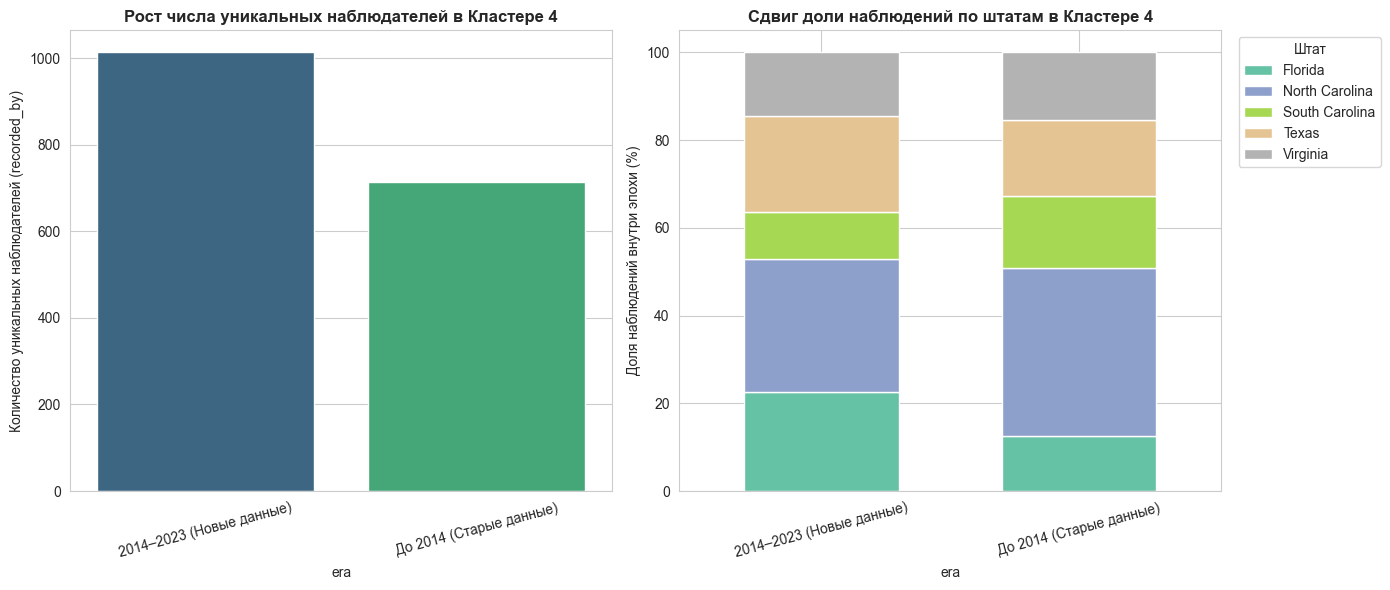

In [76]:
# Рассчитаем динамику числа уникальных наблюдателей и концентрации их наблюдений в конкретных южных штатах

# Фильтруем только Кластер 4
df_c4 = data_merged[data_merged['cluster'] == 4].copy()

# Создаем признак эпохи: последние 10 лет (2014-2023) vs более ранние данные
df_c4['era'] = np.where(df_c4['year'] >= 2014, '2014–2023 (Новые данные)', 'До 2014 (Старые данные)')

# Анализируем количество уникальных наблюдателей и общее число записей
observer_stats = df_c4.groupby('era').agg(
    total_obs=('gbif_id', 'count'),
    unique_observers=('recorded_by', 'nunique')
).reset_index()

print("Статистика по наблюдателям в Кластере 4")
print(observer_stats)

# Анализируем сдвиг по штатам (в процентах, чтобы нивелировать общий рост объема данных)
# Берем топ-5 штатов Кластера 4 за все время
top_states = df_c4['state_province'].value_counts().head(5).index.tolist()

state_shift = df_c4[df_c4['state_province'].isin(top_states)].groupby(['era', 'state_province']).size().unstack(fill_value=0)

# Переводим в проценты внутри каждой эпохи, чтобы видеть именно сдвиг доли
state_shift_pct = state_shift.div(state_shift.sum(axis=1), axis=0) * 100

print("Доля наблюдений по топ-5 штатам Кластера 4 (%)")
print(state_shift_pct.round(1))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График А: Рост числа уникальных наблюдателей
sns.barplot(data=observer_stats, x='era', y='unique_observers', ax=axes[0], palette='viridis')
axes[0].set_title('Рост числа уникальных наблюдателей в Кластере 4', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Количество уникальных наблюдателей (recorded_by)')
axes[0].tick_params(axis='x', rotation=15)

# График Б: Сдвиг доли наблюдений по штатам
state_shift_pct.plot(kind='bar', ax=axes[1], stacked=True, colormap='Set2', width=0.6)
axes[1].set_title('Сдвиг доли наблюдений по штатам в Кластере 4', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Доля наблюдений внутри эпохи (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Штат', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

Количество уникальных наблюдателей выросло с 714 до 1014 (рост на ~42%), при том что общее число наблюдений выросло не так сильно. Это означает, что в последние годы появилось много новых, вероятно, любительских наблюдателей (например, через приложения для смартфонов).

- Флорида: доля наблюдений выросла с 12.5% до 22.5% (+10 п.п.).
- Техас: доля выросла с 17.4% до 21.8% (+4.4 п.п.).
- Северная и Южная Каролина: их доля значительно упала (с 38.4% до 30.3% и с 16.2% до 10.8% соответственно).

Это создает ложный тренд: Флорида и Техас находятся южнее, чем Северная и Южная Каролина. Если в последние годы резко выросло количество наблюдений именно во Флориде и Техасе (из-за притока новых наблюдателей), то средняя арифметическая широта всего Кластера 4 математически сдвинется на юг.

Вывод: Отрицательный тренд широты в Кластере 4, который мы видели в регрессии, вызван не тем, что лебеди улетели южнее, а тем, что люди стали чаще сообщать о лебедях из более южных штатов этого кластера.

## 23. Визуализации

> TODO: постройте минимум 4 графика:
> 1. карта кластеров;
> 2. дендрограмма;
> 3. график тренда широты;
> 4. boxplot по видам.

In [77]:
# Перечисленные графики построены выше в соответствующих разделах

## 24. Выводы

> TODO: сформулируйте выводы в текстовом блоке:
> - наблюдается ли смещение ареала?
> - различается ли оно по кластерам?
> - какие различия между видами и сезонами?
> - какие ограничения анализа?

**Итоговые выводы по анализу пространственно-временной динамики ареала лебедей в США**

1. Наблюдается ли смещение ареала?

Да, смещение ареала наблюдается, но его направление зависит от географического региона. В большинстве ключевых регионов (Кластеры 1, 2 и 5) зафиксировано статистически значимое смещение ареала как зимовки, так и гнездования на север (в среднем на 60–130 км за 43 года). Это согласуется с глобальной гипотезой о влиянии изменения климата: более мягкие условия позволяют птицам оставаться в более высоких широтах.

2. Различается ли смещение по кластерам?

Да, радикально. Анализ выявил гетерогенность трендов:
- В Кластерах 1, 2 и 5 тренд устойчиво направлен на север.
- В Кластере 4 (Южное побережье) выявлен значимый тренд на смещение на юг (~200 км). Именно этот локальный южный тренд в Кластере 4, будучи агрегированным с остальными данными, создавал в первоначальной модели по всему датасету ложный эффект глобального смещения гнездования на юг (парадокс Симпсона).

3. Какие различия между видами и сезонами?

- Сезоны: В стабильных кластерах (1, 2, 5) направление тренда совпадает для обоих сезонов (север), что указывает на системное изменение климатических условий, влияющее и на места гнездования, и на места зимовки.

- Виды: Непараметрические тесты и боксплоты показали, что виды занимают разные экологические ниши. C. buccinator (Лебедь-трубач) в среднем обитает севернее всех, C. olor (Лебедь-шипун) - южнее всех и в более теплых условиях, а C. columbianus (Тундровый лебедь), занимая промежуточную широту, характеризуется самыми низкими температурами обитания (вероятно, из-за обитания в континентальном, а не прибрежном климате).

4. Ограничения анализа:

- Смещение наблюдателя (Observer Bias): Выявленный аномальный южный тренд в Кластере 4 с высокой вероятностью является артефактом сбора данных (например, резкий рост популярности приложений для гражданской науки в южных штатах в последние годы), а не реальным биологическим сдвигом популяции.

- Низкий R² в линейных моделях: Даже при статистической значимости (p < 0.05), коэффициенты детерминации (R²) остаются низкими (0.001 – 0.07). Это означает, что год объясняет лишь малую долю изменчивости широты. На распределение лебедей гораздо сильнее влияют другие, неучтенные в модели факторы: наличие конкретных водоемов, локальная кормовая база, антропогенное беспокойство или конкретные погодные аномалии в отдельные годы.

- Грубая агрегация: Использование средней температуры по штату может нивелировать локальные микроклиматические особенности, важные для птиц.